In [1]:
# import library dan dataset
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

df_data = pd.read_csv("store5.csv")

In [2]:
df_data

,id,date,store_nbr,family,sales,onpromotion,dcoilwtico
0,1452,2013-01-01,5,AUTOMOTIVE,0.000,0,NaN
1,1453,2013-01-01,5,BABY CARE,0.000,0,NaN
2,1454,2013-01-01,5,BEAUTY,0.000,0,NaN
3,1455,2013-01-01,5,BEVERAGES,0.000,0,NaN
4,1456,2013-01-01,5,BOOKS,0.000,0,NaN
...,...,...,...,...,...,...,...
55567,3000586,2017-08-15,5,POULTRY,241.011,1,47.57
55568,3000587,2017-08-15,5,PREPARED FOODS,52.121,0,47.57
55569,3000588,2017-08-15,5,PRODUCE,1357.823,4,47.57
55570,3000589,2017-08-15,5,SCHOOL AND OFFICE SUPPLIES,0.000,0,47.57


In [3]:
df_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55572 entries, 0 to 55571
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           55572 non-null  int64  
 1   date         55572 non-null  object 
 2   store_nbr    55572 non-null  int64  
 3   family       55572 non-null  object 
 4   sales        55572 non-null  float64
 5   onpromotion  55572 non-null  int64  
 6   dcoilwtico   38379 non-null  float64
dtypes: float64(2), int64(3), object(2)
memory usage: 3.0+ MB


In [4]:
df_data.describe()

,id,store_nbr,sales,onpromotion,dcoilwtico
count,5.557200e+04,55572.0,55572.000000,55572.000000,38379.000000
mean,1.501021e+06,5.0,280.580231,2.687864,67.925589
std,8.662894e+05,0.0,652.588149,11.748996,25.666659
min,1.452000e+03,5.0,0.000000,0.000000,26.190000
25%,7.512365e+05,5.0,1.000000,0.000000,46.380000
50%,1.501021e+06,5.0,19.000000,0.000000,53.330000
75%,2.250806e+06,5.0,237.000000,0.000000,95.800000
max,3.000590e+06,5.0,8216.620000,182.000000,110.620000


## Check dan Cleaning data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55572 entries, 0 to 55571
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   id           55572 non-null  int64         
 1   date         55572 non-null  datetime64[ns]
 2   store_nbr    55572 non-null  int64         
 3   family       55572 non-null  object        
 4   sales        55572 non-null  float64       
 5   onpromotion  55572 non-null  int64         
 6   dcoilwtico   38379 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(3), object(1)
memory usage: 3.0+ MB


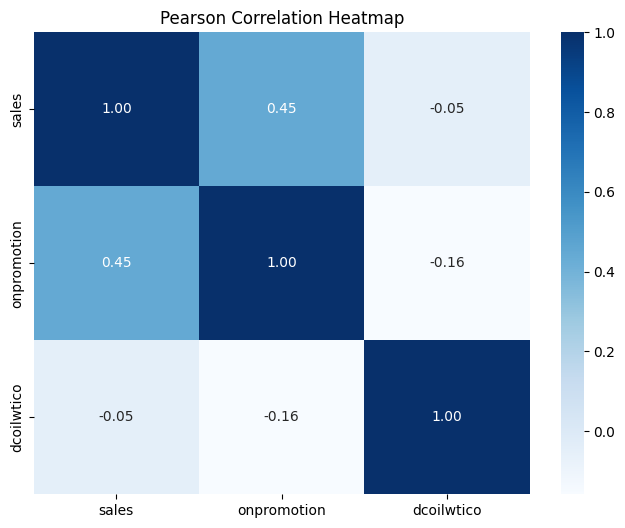

In [5]:
# Mengubah tipe data kolom date 'object' ke 'datetime'
df_data['date'] = pd.to_datetime(df_data['date'])
df_data.info()

# Memilih kolom numerik saja
numeric_cols = ['sales', 'onpromotion', 'dcoilwtico']

# Drop missing values (jika ada) agar korelasi dapat dihitung
df_numeric = df_data[numeric_cols].dropna()

# Menghitung matriks korelasi Pearson
correlation_matrix = df_numeric.corr(method='pearson')

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='Blues', fmt='.2f')
plt.title('Pearson Correlation Heatmap')
plt.show()

In [6]:
# Berdasarkan korelasi pearson diatas, varibale onpromotion sangat berpengaruh terhadap sales.
# dapat disimpulkan bahwa kita memiliki variable endogen (target) yaitu sales dan onpromotion.
# karna dcoil adalah index harga minyak dan dari korelasi juga nilai nya kecil bahkan minus jadi bisa disimpulkan dcoil adalah variable eksogen

In [7]:
# Karna kolom ID tidak terlalu berpengaruh terhadap modeling jadi bisa di hilangkan
df_store_new = df_data [['date','store_nbr','family','sales','onpromotion','dcoilwtico']]
df_store_new

,date,store_nbr,family,sales,onpromotion,dcoilwtico
0,2013-01-01,5,AUTOMOTIVE,0.000,0,NaN
1,2013-01-01,5,BABY CARE,0.000,0,NaN
2,2013-01-01,5,BEAUTY,0.000,0,NaN
3,2013-01-01,5,BEVERAGES,0.000,0,NaN
4,2013-01-01,5,BOOKS,0.000,0,NaN
...,...,...,...,...,...,...
55567,2017-08-15,5,POULTRY,241.011,1,47.57
55568,2017-08-15,5,PREPARED FOODS,52.121,0,47.57
55569,2017-08-15,5,PRODUCE,1357.823,4,47.57
55570,2017-08-15,5,SCHOOL AND OFFICE SUPPLIES,0.000,0,47.57


In [8]:
# karna data time series cek apakah ada missing date
# membuat rentang tanggal lengkap berdasarkan min & max
full_date_range = pd.date_range(start=df_store_new['date'].min(), end=df_store_new['date'].max(), freq='D')

# Cari dan tampilkan tanggal yang hilang
print(full_date_range.difference(df_store_new['date']))

DatetimeIndex(['2013-12-25', '2014-12-25', '2015-12-25', '2016-12-25'], dtype='datetime64[ns]', freq=None)


In [9]:
# Handle Missing date
# Membuat dataframe dengan sort kombinasi unik dari family dan store_nbr
store_family_combinations = df_store_new[['store_nbr', 'family']].drop_duplicates()

# Daftar untuk menyimpan baris dengan tanggal yang hilang
missing_data = []

for _, row in store_family_combinations.iterrows():
    store_nbr = row['store_nbr']
    family = row['family']

    # Filter data untuk kombinasi store_nbr dan family tertentu
    family_data = df_store_new[(df_store_new['store_nbr'] == store_nbr) & (df_store_new['family'] == family)]

    # Cari tanggal yang hilang untuk kombinasi ini
    missing_dates = full_date_range.difference(family_data['date'])

    # Simpan hasilnya dalam bentuk data baru
    for missing_date in missing_dates:
        missing_data.append({
            'store_nbr': store_nbr,
            'family': family,
            'date': missing_date,
            'sales': 0,  # Menetapkan nilai default untuk sales
            'onpromotion': 0,  # Nilai default untuk onpromotion
            'dcoilwtico': None  # Nilai default untuk dcoilwtico
        })

# Buat DataFrame untuk missing data
missing_df = pd.DataFrame(missing_data)

# Gabungkan missing data ke df_store_new
df_store_full = pd.concat([df_store_new, missing_df], ignore_index=True)

# Urutkan berdasarkan store_nbr, family, dan date
df_store_full = df_store_full.sort_values(by=['store_nbr', 'family', 'date']).reset_index(drop=True)

# Menampilkan hasil
df_store_full

<ipython-input-9-123976dddff4>:33: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_store_full = pd.concat([df_store_new, missing_df], ignore_index=True)


,date,store_nbr,family,sales,onpromotion,dcoilwtico
0,2013-01-01,5,AUTOMOTIVE,0.000,0,NaN
1,2013-01-02,5,AUTOMOTIVE,6.000,0,93.14
2,2013-01-03,5,AUTOMOTIVE,4.000,0,92.97
3,2013-01-04,5,AUTOMOTIVE,6.000,0,93.12
4,2013-01-05,5,AUTOMOTIVE,4.000,0,NaN
...,...,...,...,...,...,...
55699,2017-08-11,5,SEAFOOD,8.402,4,48.81
55700,2017-08-12,5,SEAFOOD,7.320,0,NaN
55701,2017-08-13,5,SEAFOOD,11.642,0,NaN
55702,2017-08-14,5,SEAFOOD,11.694,0,47.59


In [10]:
# Cek bulan desember karna tanggal yang hilang berpola yaitu setiap tanggal 25 desember setiap tahunnya.
df_december = df_store_full[df_store_full['date'].dt.month == 12]
print(df_december.head(60), '\n')
print(df_december.tail(60))

          date  store_nbr      family  sales  onpromotion  dcoilwtico
334 2013-12-01          5  AUTOMOTIVE   16.0            0         NaN
335 2013-12-02          5  AUTOMOTIVE   11.0            0       93.61
336 2013-12-03          5  AUTOMOTIVE    2.0            0       95.83
337 2013-12-04          5  AUTOMOTIVE    2.0            0       96.97
338 2013-12-05          5  AUTOMOTIVE    7.0            0       97.14
339 2013-12-06          5  AUTOMOTIVE    2.0            0       97.48
340 2013-12-07          5  AUTOMOTIVE    2.0            0         NaN
341 2013-12-08          5  AUTOMOTIVE   12.0            0         NaN
342 2013-12-09          5  AUTOMOTIVE    8.0            0       97.10
343 2013-12-10          5  AUTOMOTIVE    2.0            0       98.32
344 2013-12-11          5  AUTOMOTIVE    2.0            0       97.25
345 2013-12-12          5  AUTOMOTIVE    6.0            0       97.21
346 2013-12-13          5  AUTOMOTIVE    1.0            0       96.27
347 2013-12-14      

In [11]:
df_store_full.describe()

,date,store_nbr,sales,onpromotion,dcoilwtico
count,55704,55704.0,55704.000000,55704.000000,38379.000000
mean,2015-04-24 11:59:59.999999744,5.0,279.915348,2.681495,67.925589
min,2013-01-01 00:00:00,5.0,0.000000,0.000000,26.190000
25%,2014-02-26 18:00:00,5.0,1.000000,0.000000,46.380000
50%,2015-04-24 12:00:00,5.0,19.000000,0.000000,53.330000
75%,2016-06-19 06:00:00,5.0,236.402750,0.000000,95.800000
max,2017-08-15 00:00:00,5.0,8216.620000,182.000000,110.620000
std,NaN,0.0,651.957218,11.735794,25.666659


In [12]:
# Hitung total sales per family dan ambil top 3
top_3_families = (
    df_store_full.groupby('family')['sales']
    .sum()
    .sort_values(ascending=False)
    .head(3)
)

print(top_3_families)

family
GROCERY I    5262681.658
BEVERAGES    2533831.000
CLEANING     1667748.000
Name: sales, dtype: float64


## Family Cleaning

In [13]:
# Filter hanya data dengan family "CLEANING"
df_cleaning = df_store_full[df_store_full["family"] == "CLEANING"]
df_cleaning

,date,store_nbr,family,sales,onpromotion,dcoilwtico
11816,2013-01-01,5,CLEANING,0.0,0,NaN
11817,2013-01-02,5,CLEANING,1810.0,0,93.14
11818,2013-01-03,5,CLEANING,1305.0,0,92.97
11819,2013-01-04,5,CLEANING,1159.0,0,93.12
11820,2013-01-05,5,CLEANING,1257.0,0,NaN
...,...,...,...,...,...,...
13499,2017-08-11,5,CLEANING,775.0,16,48.81
13500,2017-08-12,5,CLEANING,686.0,14,NaN
13501,2017-08-13,5,CLEANING,927.0,16,NaN
13502,2017-08-14,5,CLEANING,676.0,10,47.59


In [14]:
# Cek missing value

missing_per_column = df_cleaning.isna().sum()

# Menampilkan kolom yang memiliki missing values
columns_with_missing = missing_per_column[missing_per_column > 0]

print("Kolom dengan nilai missing (NaN):")
print(columns_with_missing)

# Menampilkan persentase missing per kolom
missing_percentage_per_column = (columns_with_missing / len(df_cleaning)) * 100
print("\nPersentase missing (NaN):")
print(missing_percentage_per_column)

Kolom dengan nilai missing (NaN):
dcoilwtico    525
dtype: int64

Persentase missing (NaN):
dcoilwtico    31.101896
dtype: float64


In [15]:
# dcoilwtico terdapat sekitar 31% missing value yang dimana cukup besar dari total data yang ada.

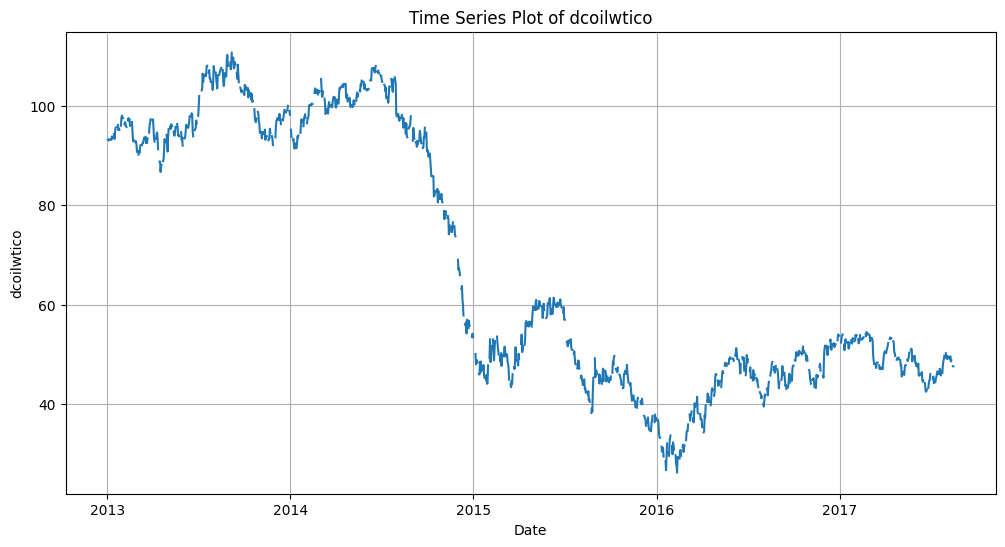

In [16]:
# Handle Missing value Dcoilwtico

# Cek time series plot dcoilwtico
plt.figure(figsize=(12, 6))
plt.plot(df_cleaning['date'], df_cleaning['dcoilwtico'])
plt.title('Time Series Plot of dcoilwtico')
plt.xlabel('Date')
plt.ylabel('dcoilwtico')
plt.grid(True)
plt.show()

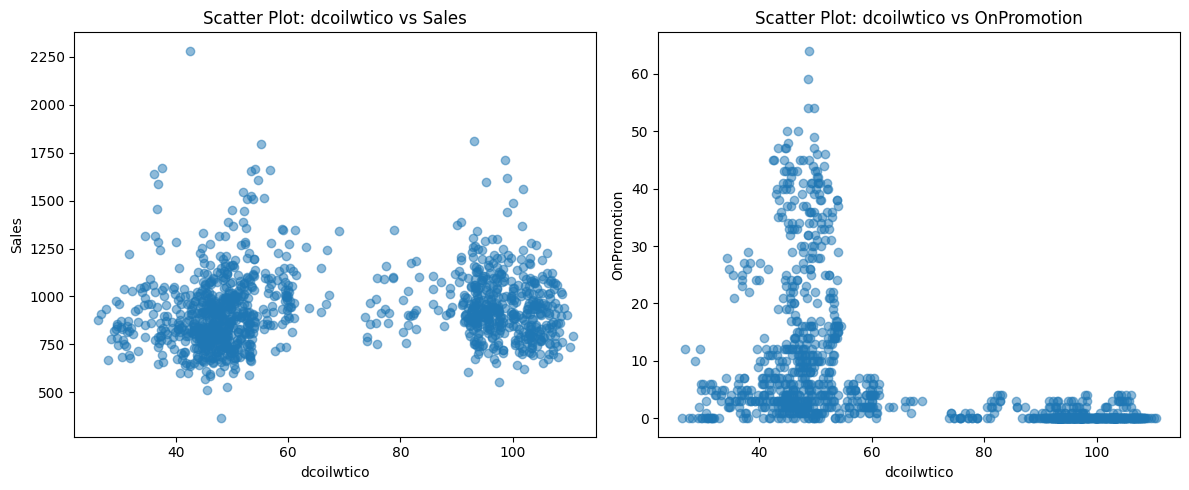

In [17]:
# Cek sebaran data
# Scatter plot dcoilwtico vs sales
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(df_cleaning["dcoilwtico"], df_cleaning["sales"], alpha=0.5)
plt.xlabel("dcoilwtico")
plt.ylabel("Sales")
plt.title("Scatter Plot: dcoilwtico vs Sales")

# Scatter plot dcoilwtico vs onpromotion
plt.subplot(1, 2, 2)
plt.scatter(df_cleaning["dcoilwtico"], df_cleaning["onpromotion"], alpha=0.5)
plt.xlabel("dcoilwtico")
plt.ylabel("OnPromotion")
plt.title("Scatter Plot: dcoilwtico vs OnPromotion")

plt.tight_layout()
plt.show()

In [18]:
# Berdasarkan Scatter dan time series plot, sebaran dan pola data tidak menunjukkan garis lurus jadi metode linear tidak memungkinkan.
# karna ada lonjakan dan variasi jadi lebih baik dihandle menggunakan metode Polynomial
df_cleaning['dcoilwtico_interpolate_polynomial'] = df_cleaning['dcoilwtico'].interpolate(method='polynomial', order = 2)

# karna ada data awal yang kosong maka pakai forward/backward fill unntuk mengisi missing date nya
df_cleaning['dcoilwtico_interpolate_polynomial'].fillna(method='bfill', inplace=True) # Mengisi dengan nilai sebelumnya

<ipython-input-18-e0b0a042fc6c>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaning['dcoilwtico_interpolate_polynomial'] = df_cleaning['dcoilwtico'].interpolate(method='polynomial', order = 2)
<ipython-input-18-e0b0a042fc6c>:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_cl

In [19]:
# Cek setelah interpolasi
print(df_cleaning.isna().sum())

date                                   0
store_nbr                              0
family                                 0
sales                                  0
onpromotion                            0
dcoilwtico                           525
dcoilwtico_interpolate_polynomial      0
dtype: int64


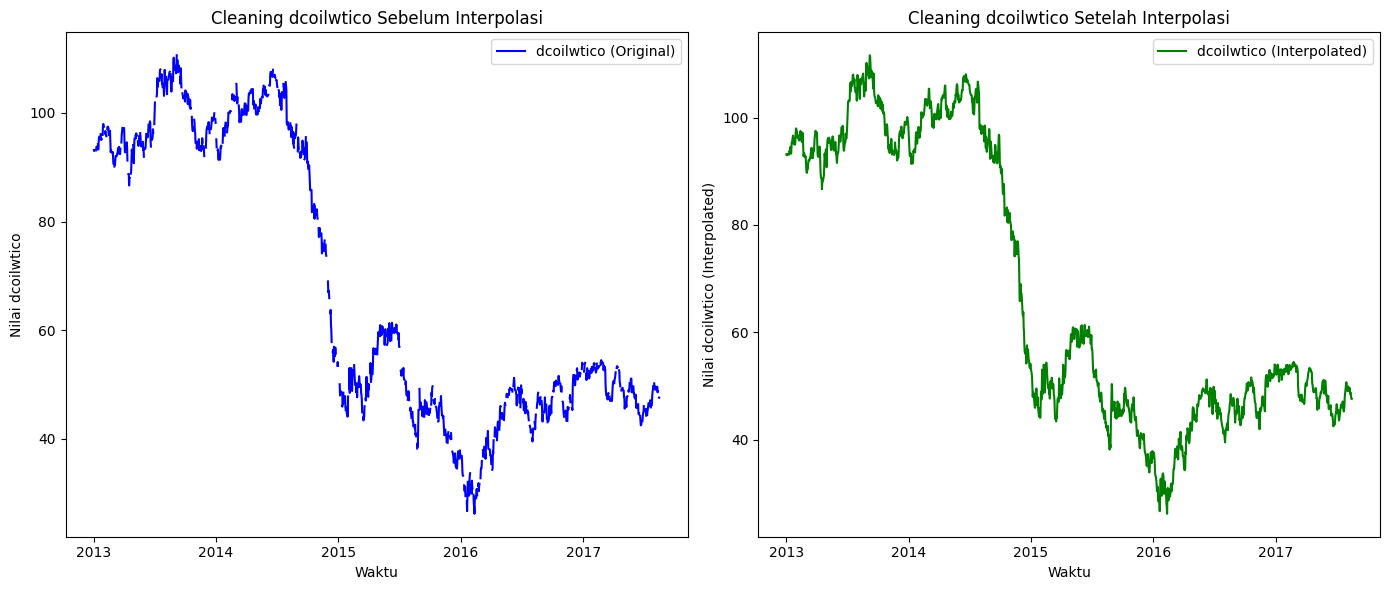

In [20]:
# Membuat plot perbandingan sebelum dan sesudah interpolasi
plt.figure(figsize=(14, 6))

# Plot dcoilwtico sebelum interpolasi
plt.subplot(1, 2, 1)
plt.plot(df_cleaning['date'], df_cleaning['dcoilwtico'], label='dcoilwtico (Original)', color='blue')
plt.title('Cleaning dcoilwtico Sebelum Interpolasi')
plt.xlabel('Waktu')
plt.ylabel('Nilai dcoilwtico')
plt.legend()

# Plot dcoilwtico setelah interpolasi
plt.subplot(1, 2, 2)
plt.plot(df_cleaning['date'], df_cleaning['dcoilwtico_interpolate_polynomial'], label='dcoilwtico (Interpolated)', color='green')
plt.title('Cleaning dcoilwtico Setelah Interpolasi')
plt.xlabel('Waktu')
plt.ylabel('Nilai dcoilwtico (Interpolated)')
plt.legend()

plt.tight_layout()
plt.show()

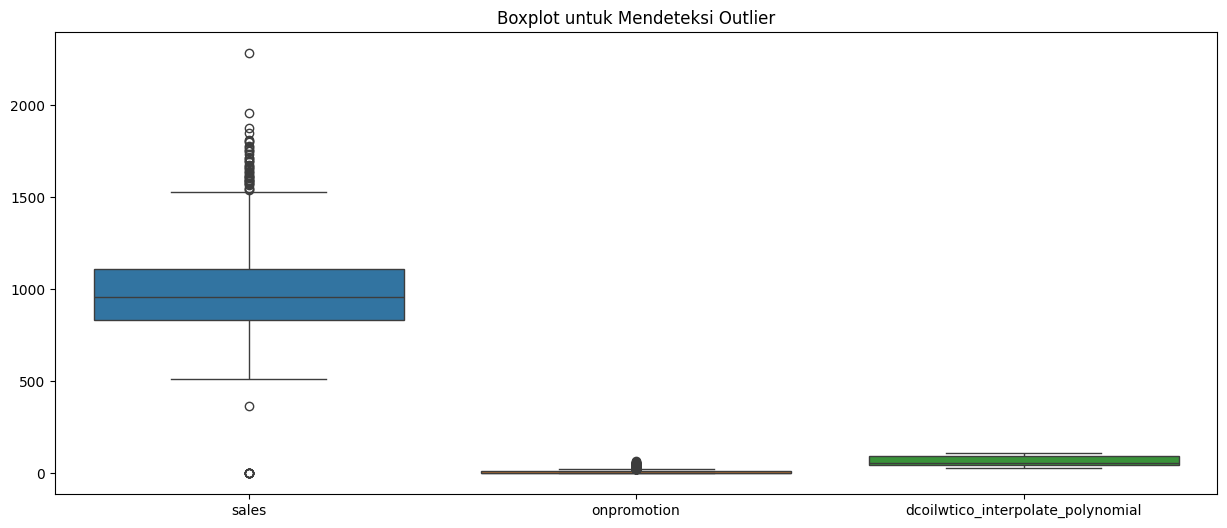

In [21]:
# cek outlier
plt.figure(figsize=(15, 6))
sns.boxplot(data=df_cleaning[['sales', 'onpromotion', 'dcoilwtico_interpolate_polynomial']])
plt.title('Boxplot untuk Mendeteksi Outlier')
plt.show()

In [22]:
# dari boxplot terdapat outlier yang banyak di sales dan lainnya lebih sedikit.
# tetapi untuk menghindari take-out bebrapa data jadi outlier pada data tidak di handling

In [23]:
df_cleaning_original = df_cleaning.copy()

## EDA

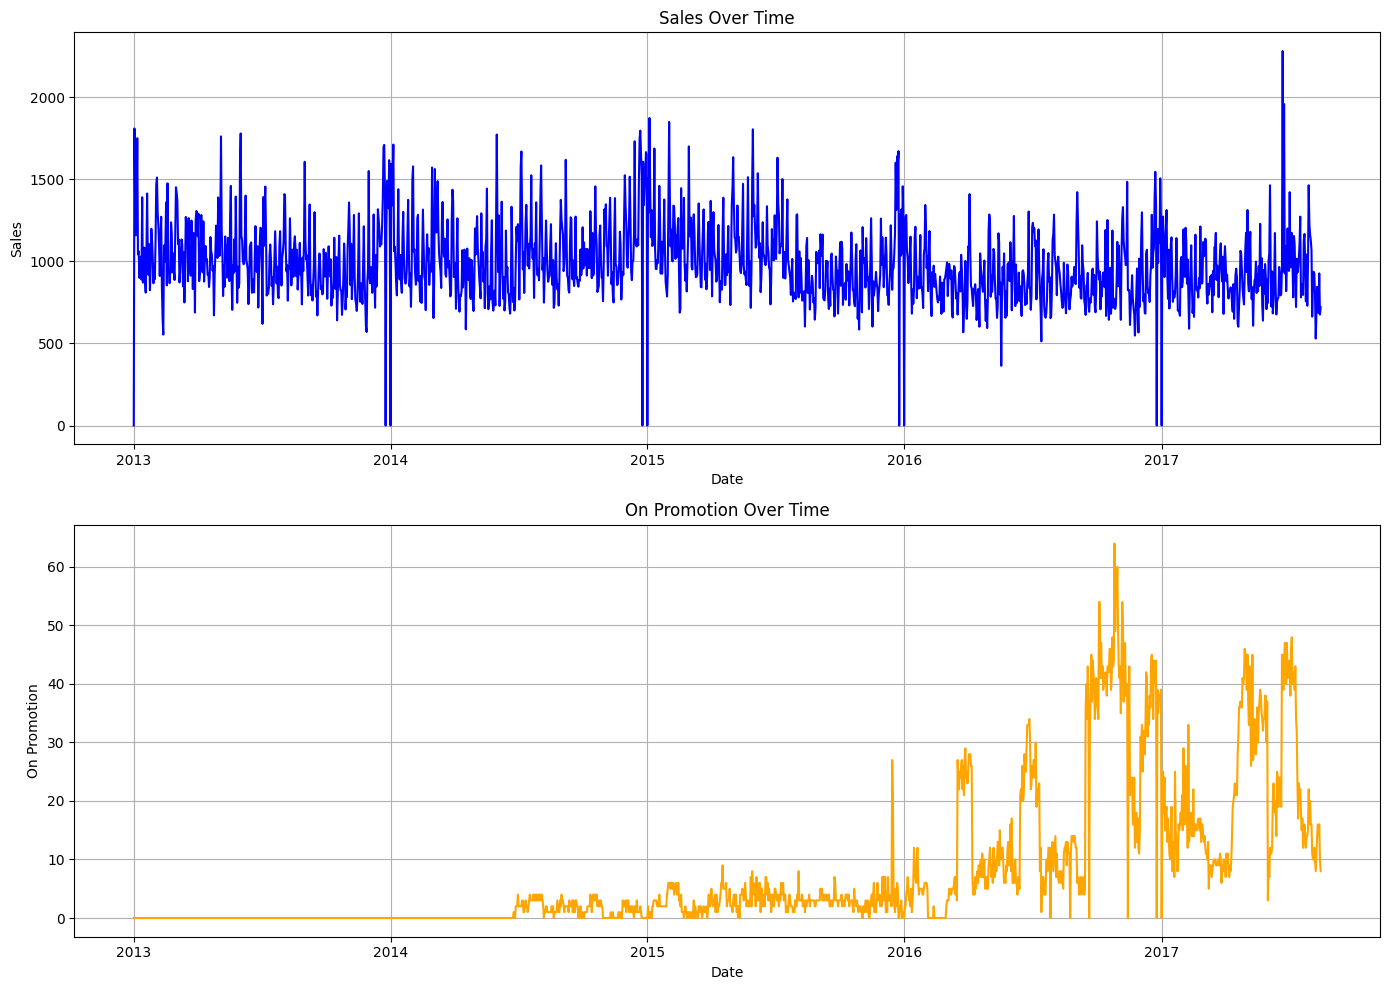

In [24]:
# cek plot data melihat stationer atau tidak karna akan menggunakan modeling varmax

plt.figure(figsize=(14, 10), facecolor='white')

# Plot Sales
plt.subplot(2, 1, 1)
plt.plot(df_cleaning['date'], df_cleaning['sales'], color='blue')
plt.title("Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.grid(True)

# Plot On Promotion
plt.subplot(2, 1, 2)
plt.plot(df_cleaning['date'], df_cleaning['onpromotion'], color='orange')
plt.title("On Promotion Over Time")
plt.xlabel("Date")
plt.ylabel("On Promotion")
plt.grid(True)

plt.tight_layout()
plt.show()

In [25]:
# cek juga adf statistik apakah stationer atau tidak
from statsmodels.tsa.stattools import adfuller

# Melakukan uji ADF pada kolom 'sales'
# Fungsi untuk ADF Test dan menampilkan hasil lengkap
def adf_test(series, series_name="Time Series"):
    result = adfuller(series.dropna())
    # Menampilkan hasil uji
    print(f"\nADF Test for {series_name}:")
    print("ADF Statistic:", result[0])
    print("p-value:", result[1])
    print("Lags Used:", result[2])
    print("Number of Observations Used:", result[3])
    print("Critical Values:")
    for key, value in result[4].items():
        print(f"   {key}: {value}")
    if result[1] < 0.05:
        print("\nData stasioner (reject H0)")
    else:
        print("\nData tidak stasioner (fail to reject H0)")

# ADF test untuk sales dan onpromotion
adf_test(df_cleaning['sales'], "Sales")
adf_test(df_cleaning['onpromotion'], "OnPromotion")


ADF Test for Sales:
ADF Statistic: -5.3878447137977465
p-value: 3.5921165826560076e-06
Lags Used: 22
Number of Observations Used: 1665
Critical Values:
   1%: -3.434283579780684
   5%: -2.863277451883613
   10%: -2.5676949772294817

Data stasioner (reject H0)

ADF Test for OnPromotion:
ADF Statistic: -2.8026181978589038
p-value: 0.057900749308591876
Lags Used: 24
Number of Observations Used: 1663
Critical Values:
   1%: -3.434288317816291
   5%: -2.863279543282764
   10%: -2.5676960908695463

Data tidak stasioner (fail to reject H0)


In [26]:
# Handle Stationer with Boxcox
from scipy.stats import boxcox

df_cleaning['onpromotion_boxcox'], lambda_bc = boxcox(df_cleaning['onpromotion'] +1)
df_cleaning

<ipython-input-26-2bb1bde97cf2>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaning['onpromotion_boxcox'], lambda_bc = boxcox(df_cleaning['onpromotion'] +1)


,date,store_nbr,family,sales,onpromotion,dcoilwtico,dcoilwtico_interpolate_polynomial,onpromotion_boxcox
11816,2013-01-01,5,CLEANING,0.0,0,NaN,93.140000,0.000000
11817,2013-01-02,5,CLEANING,1810.0,0,93.14,93.140000,0.000000
11818,2013-01-03,5,CLEANING,1305.0,0,92.97,92.970000,0.000000
11819,2013-01-04,5,CLEANING,1159.0,0,93.12,93.120000,0.000000
11820,2013-01-05,5,CLEANING,1257.0,0,NaN,93.205338,0.000000
...,...,...,...,...,...,...,...,...
13499,2017-08-11,5,CLEANING,775.0,16,48.81,48.810000,1.963158
13500,2017-08-12,5,CLEANING,686.0,14,NaN,48.717426,1.905055
13501,2017-08-13,5,CLEANING,927.0,16,NaN,48.020802,1.963158
13502,2017-08-14,5,CLEANING,676.0,10,47.59,47.590000,1.752087


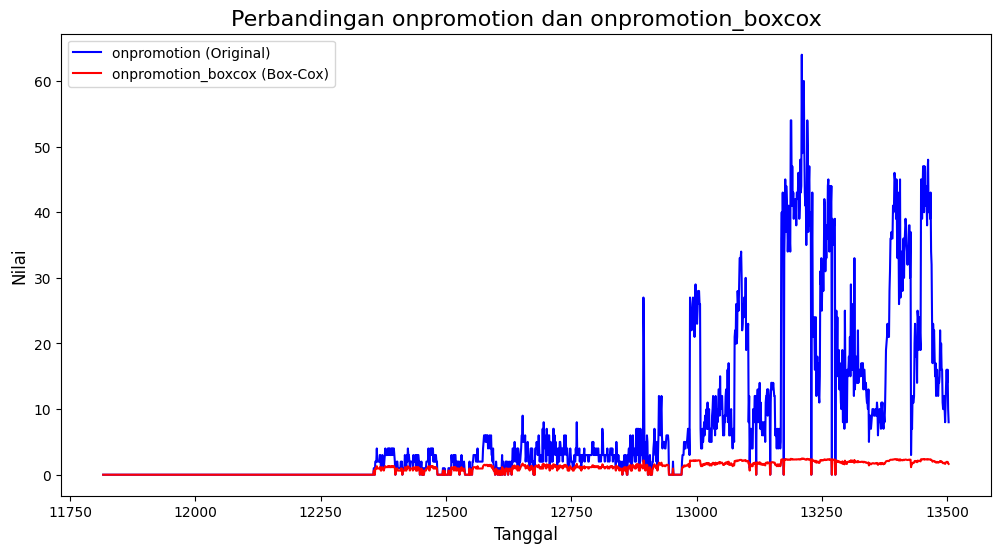

In [27]:
# Cek perbandingan sebelum dan sesudah plot box-cox
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Plot 'onpromotion' (data asli)
plt.plot(df_cleaning.index, df_cleaning['onpromotion'], label='onpromotion (Original)', color='blue')

# Plot 'onpromotion_boxcox' (setelah Box-Cox)
plt.plot(df_cleaning.index, df_cleaning['onpromotion_boxcox'], label='onpromotion_boxcox (Box-Cox)', color='red')

# Menambahkan label dan judul
plt.title('Perbandingan onpromotion dan onpromotion_boxcox', fontsize=16)
plt.xlabel('Tanggal', fontsize=12)
plt.ylabel('Nilai', fontsize=12)

# Menambahkan legenda
plt.legend()

# Menampilkan plot
plt.show()

In [28]:
# Melakukan uji ADF pada kolom 'onpromotion box-cox'
adf_test(df_cleaning['onpromotion_boxcox'], "OnPromotion box cox")


ADF Test for OnPromotion box cox:
ADF Statistic: -2.418638882501888
p-value: 0.136544677324771
Lags Used: 9
Number of Observations Used: 1678
Critical Values:
   1%: -3.4342530582756807
   5%: -2.8632639794173427
   10%: -2.5676878033472508

Data tidak stasioner (fail to reject H0)


In [29]:
# Log Transformasi
df_cleaning['onpromotion_log'] = np.log(df_cleaning['onpromotion'] + 1 )
df_cleaning

<ipython-input-29-f5c5b9db4a5c>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaning['onpromotion_log'] = np.log(df_cleaning['onpromotion'] + 1 )


,date,store_nbr,family,sales,onpromotion,dcoilwtico,dcoilwtico_interpolate_polynomial,onpromotion_boxcox,onpromotion_log
11816,2013-01-01,5,CLEANING,0.0,0,NaN,93.140000,0.000000,0.000000
11817,2013-01-02,5,CLEANING,1810.0,0,93.14,93.140000,0.000000,0.000000
11818,2013-01-03,5,CLEANING,1305.0,0,92.97,92.970000,0.000000,0.000000
11819,2013-01-04,5,CLEANING,1159.0,0,93.12,93.120000,0.000000,0.000000
11820,2013-01-05,5,CLEANING,1257.0,0,NaN,93.205338,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...
13499,2017-08-11,5,CLEANING,775.0,16,48.81,48.810000,1.963158,2.833213
13500,2017-08-12,5,CLEANING,686.0,14,NaN,48.717426,1.905055,2.708050
13501,2017-08-13,5,CLEANING,927.0,16,NaN,48.020802,1.963158,2.833213
13502,2017-08-14,5,CLEANING,676.0,10,47.59,47.590000,1.752087,2.397895


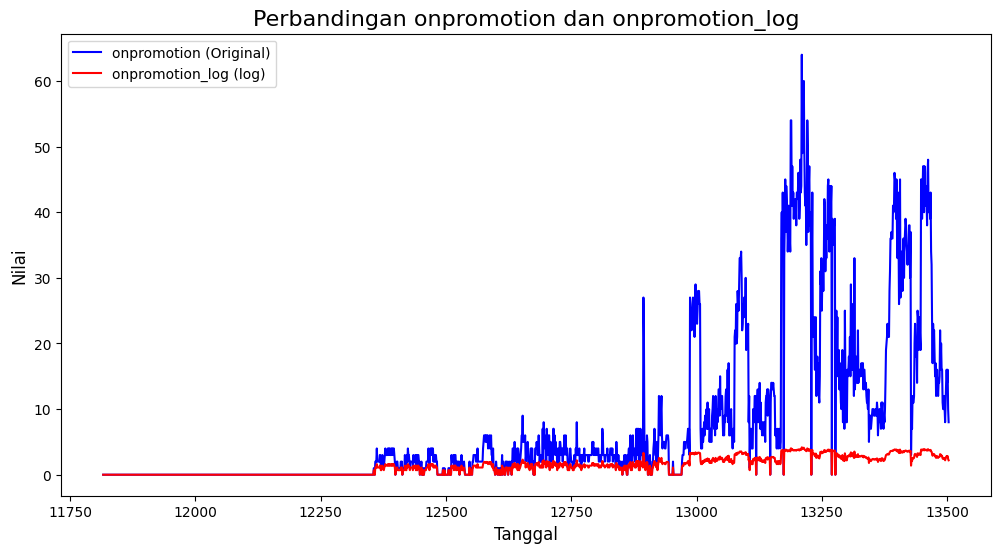

In [30]:
# Cek perbandingan sebelum dan sesudah plot log transform
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Plot 'onpromotion' (data asli)
plt.plot(df_cleaning.index, df_cleaning['onpromotion'], label='onpromotion (Original)', color='blue')

# Plot 'onpromotion_boxcox' (setelah Box-Cox)
plt.plot(df_cleaning.index, df_cleaning['onpromotion_log'], label='onpromotion_log (log)', color='red')

# Menambahkan label dan judul
plt.title('Perbandingan onpromotion dan onpromotion_log', fontsize=16)
plt.xlabel('Tanggal', fontsize=12)
plt.ylabel('Nilai', fontsize=12)

# Menambahkan legenda
plt.legend()

# Menampilkan plot
plt.show()

In [31]:
# Melakukan uji ADF pada kolom 'onpromotion log'
adf_test(df_cleaning['onpromotion_log'], "OnPromotion log")


ADF Test for OnPromotion log:
ADF Statistic: -2.4112943409290875
p-value: 0.13857400626925037
Lags Used: 9
Number of Observations Used: 1678
Critical Values:
   1%: -3.4342530582756807
   5%: -2.8632639794173427
   10%: -2.5676878033472508

Data tidak stasioner (fail to reject H0)


In [32]:
# Kombinasi Boxcox dan Log Transformasi
df_cleaning['onpromotion_boxlog'] = np.log(df_cleaning['onpromotion_boxcox'] + 1 )
df_cleaning

<ipython-input-32-714bbd078969>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaning['onpromotion_boxlog'] = np.log(df_cleaning['onpromotion_boxcox'] + 1 )


,date,store_nbr,family,sales,onpromotion,dcoilwtico,dcoilwtico_interpolate_polynomial,onpromotion_boxcox,onpromotion_log,onpromotion_boxlog
11816,2013-01-01,5,CLEANING,0.0,0,NaN,93.140000,0.000000,0.000000,0.000000
11817,2013-01-02,5,CLEANING,1810.0,0,93.14,93.140000,0.000000,0.000000,0.000000
11818,2013-01-03,5,CLEANING,1305.0,0,92.97,92.970000,0.000000,0.000000,0.000000
11819,2013-01-04,5,CLEANING,1159.0,0,93.12,93.120000,0.000000,0.000000,0.000000
11820,2013-01-05,5,CLEANING,1257.0,0,NaN,93.205338,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...
13499,2017-08-11,5,CLEANING,775.0,16,48.81,48.810000,1.963158,2.833213,1.086256
13500,2017-08-12,5,CLEANING,686.0,14,NaN,48.717426,1.905055,2.708050,1.066452
13501,2017-08-13,5,CLEANING,927.0,16,NaN,48.020802,1.963158,2.833213,1.086256
13502,2017-08-14,5,CLEANING,676.0,10,47.59,47.590000,1.752087,2.397895,1.012360


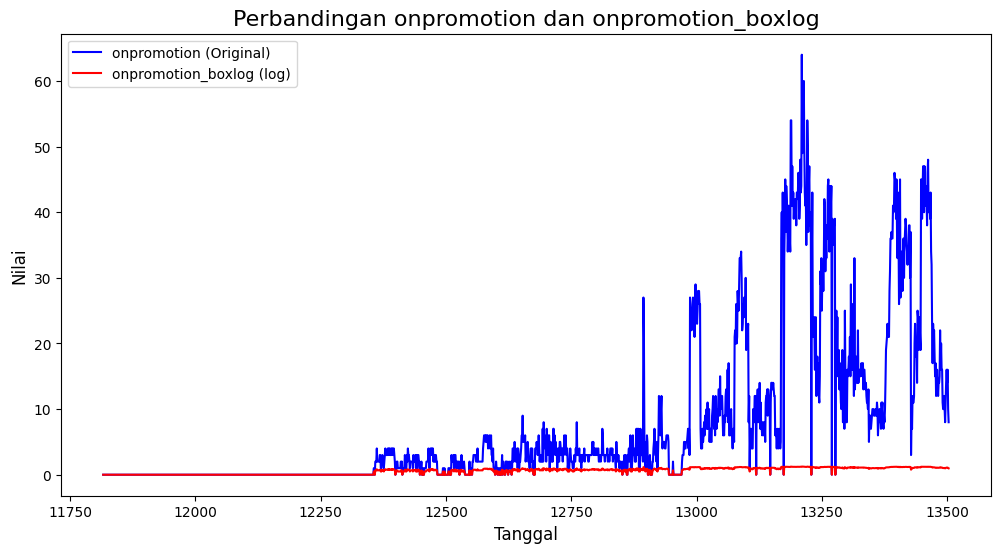

In [33]:
# Cek perbandingan sebelum dan sesudah plot boxcox dan log transform
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Plot 'onpromotion' (data asli)
plt.plot(df_cleaning.index, df_cleaning['onpromotion'], label='onpromotion (Original)', color='blue')

# Plot 'onpromotion_boxcox' (setelah Box-Cox)
plt.plot(df_cleaning.index, df_cleaning['onpromotion_boxlog'], label='onpromotion_boxlog (log)', color='red')

# Menambahkan label dan judul
plt.title('Perbandingan onpromotion dan onpromotion_boxlog', fontsize=16)
plt.xlabel('Tanggal', fontsize=12)
plt.ylabel('Nilai', fontsize=12)

# Menambahkan legenda
plt.legend()

# Menampilkan plot
plt.show()

In [34]:
# Melakukan uji ADF pada kolom 'onpromotion log'
adf_test(df_cleaning['onpromotion_boxlog'], "OnPromotion boxlog")


ADF Test for OnPromotion boxlog:
ADF Statistic: -2.5555439667313444
p-value: 0.10253785533940313
Lags Used: 9
Number of Observations Used: 1678
Critical Values:
   1%: -3.4342530582756807
   5%: -2.8632639794173427
   10%: -2.5676878033472508

Data tidak stasioner (fail to reject H0)


In [35]:
# Differencing
df_cleaning['onpromotion_diff'] = df_cleaning['onpromotion'].diff()
df_cleaning

<ipython-input-35-b310b8b3b59c>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaning['onpromotion_diff'] = df_cleaning['onpromotion'].diff()


,date,store_nbr,family,sales,onpromotion,dcoilwtico,dcoilwtico_interpolate_polynomial,onpromotion_boxcox,onpromotion_log,onpromotion_boxlog,onpromotion_diff
11816,2013-01-01,5,CLEANING,0.0,0,NaN,93.140000,0.000000,0.000000,0.000000,NaN
11817,2013-01-02,5,CLEANING,1810.0,0,93.14,93.140000,0.000000,0.000000,0.000000,0.0
11818,2013-01-03,5,CLEANING,1305.0,0,92.97,92.970000,0.000000,0.000000,0.000000,0.0
11819,2013-01-04,5,CLEANING,1159.0,0,93.12,93.120000,0.000000,0.000000,0.000000,0.0
11820,2013-01-05,5,CLEANING,1257.0,0,NaN,93.205338,0.000000,0.000000,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...
13499,2017-08-11,5,CLEANING,775.0,16,48.81,48.810000,1.963158,2.833213,1.086256,2.0
13500,2017-08-12,5,CLEANING,686.0,14,NaN,48.717426,1.905055,2.708050,1.066452,-2.0
13501,2017-08-13,5,CLEANING,927.0,16,NaN,48.020802,1.963158,2.833213,1.086256,2.0
13502,2017-08-14,5,CLEANING,676.0,10,47.59,47.590000,1.752087,2.397895,1.012360,-6.0


In [36]:
# Melakukan uji ADF pada kolom 'onpromotion_diff'
df_cleaning.dropna(inplace=True) # take out data NaN
adf_test(df_cleaning['onpromotion_diff'], "OnPromotion Diff")

<ipython-input-36-6ea197e67079>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaning.dropna(inplace=True) # take out data NaN



ADF Test for OnPromotion Diff:
ADF Statistic: -10.303950821400385
p-value: 3.31626244718267e-18
Lags Used: 16
Number of Observations Used: 1146
Critical Values:
   1%: -3.4360690296267338
   5%: -2.864065327292836
   10%: -2.568114547237679

Data stasioner (reject H0)


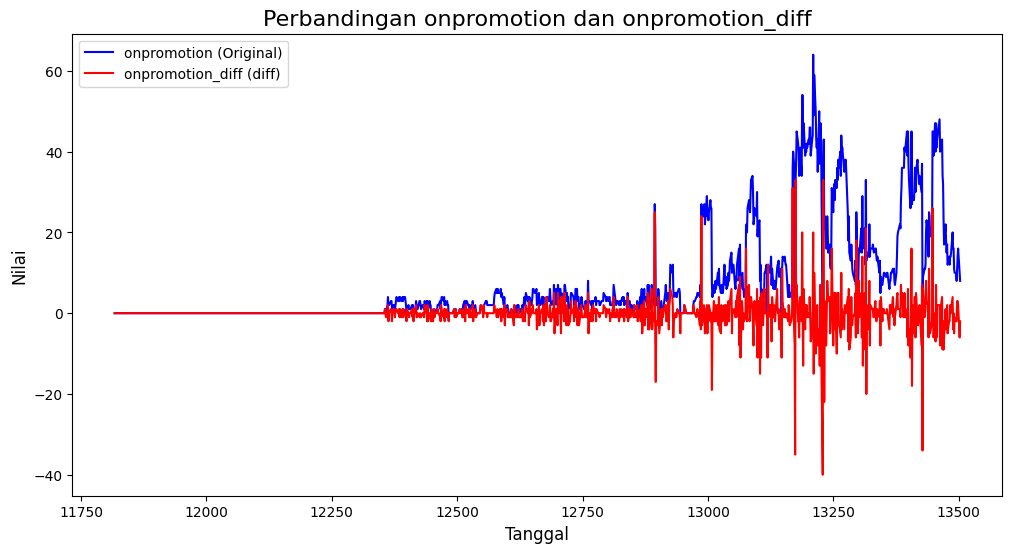

In [37]:
# Cek perbandingan sebelum dan sesudah plot differencing
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Plot 'onpromotion' (data asli)
plt.plot(df_cleaning.index, df_cleaning['onpromotion'], label='onpromotion (Original)', color='blue')

# Plot 'onpromotion_boxcox' (setelah Box-Cox)
plt.plot(df_cleaning.index, df_cleaning['onpromotion_diff'], label='onpromotion_diff (diff)', color='red')

# Menambahkan label dan judul
plt.title('Perbandingan onpromotion dan onpromotion_diff', fontsize=16)
plt.xlabel('Tanggal', fontsize=12)
plt.ylabel('Nilai', fontsize=12)

# Menambahkan legenda
plt.legend()

# Menampilkan plot
plt.show()

In [38]:
df_cleaning

,date,store_nbr,family,sales,onpromotion,dcoilwtico,dcoilwtico_interpolate_polynomial,onpromotion_boxcox,onpromotion_log,onpromotion_boxlog,onpromotion_diff
11817,2013-01-02,5,CLEANING,1810.0,0,93.14,93.14,0.000000,0.000000,0.000000,0.0
11818,2013-01-03,5,CLEANING,1305.0,0,92.97,92.97,0.000000,0.000000,0.000000,0.0
11819,2013-01-04,5,CLEANING,1159.0,0,93.12,93.12,0.000000,0.000000,0.000000,0.0
11822,2013-01-07,5,CLEANING,1043.0,0,93.20,93.20,0.000000,0.000000,0.000000,0.0
11823,2013-01-08,5,CLEANING,1062.0,0,93.21,93.21,0.000000,0.000000,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...
13497,2017-08-09,5,CLEANING,687.0,11,49.59,49.59,1.796335,2.484907,1.028310,3.0
13498,2017-08-10,5,CLEANING,845.0,14,48.54,48.54,1.905055,2.708050,1.066452,3.0
13499,2017-08-11,5,CLEANING,775.0,16,48.81,48.81,1.963158,2.833213,1.086256,2.0
13502,2017-08-14,5,CLEANING,676.0,10,47.59,47.59,1.752087,2.397895,1.012360,-6.0


<ipython-input-39-35e9d527830f>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaning['date'] = pd.to_datetime(df_cleaning['date'])
<ipython-input-39-35e9d527830f>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaning.dropna(inplace=True)


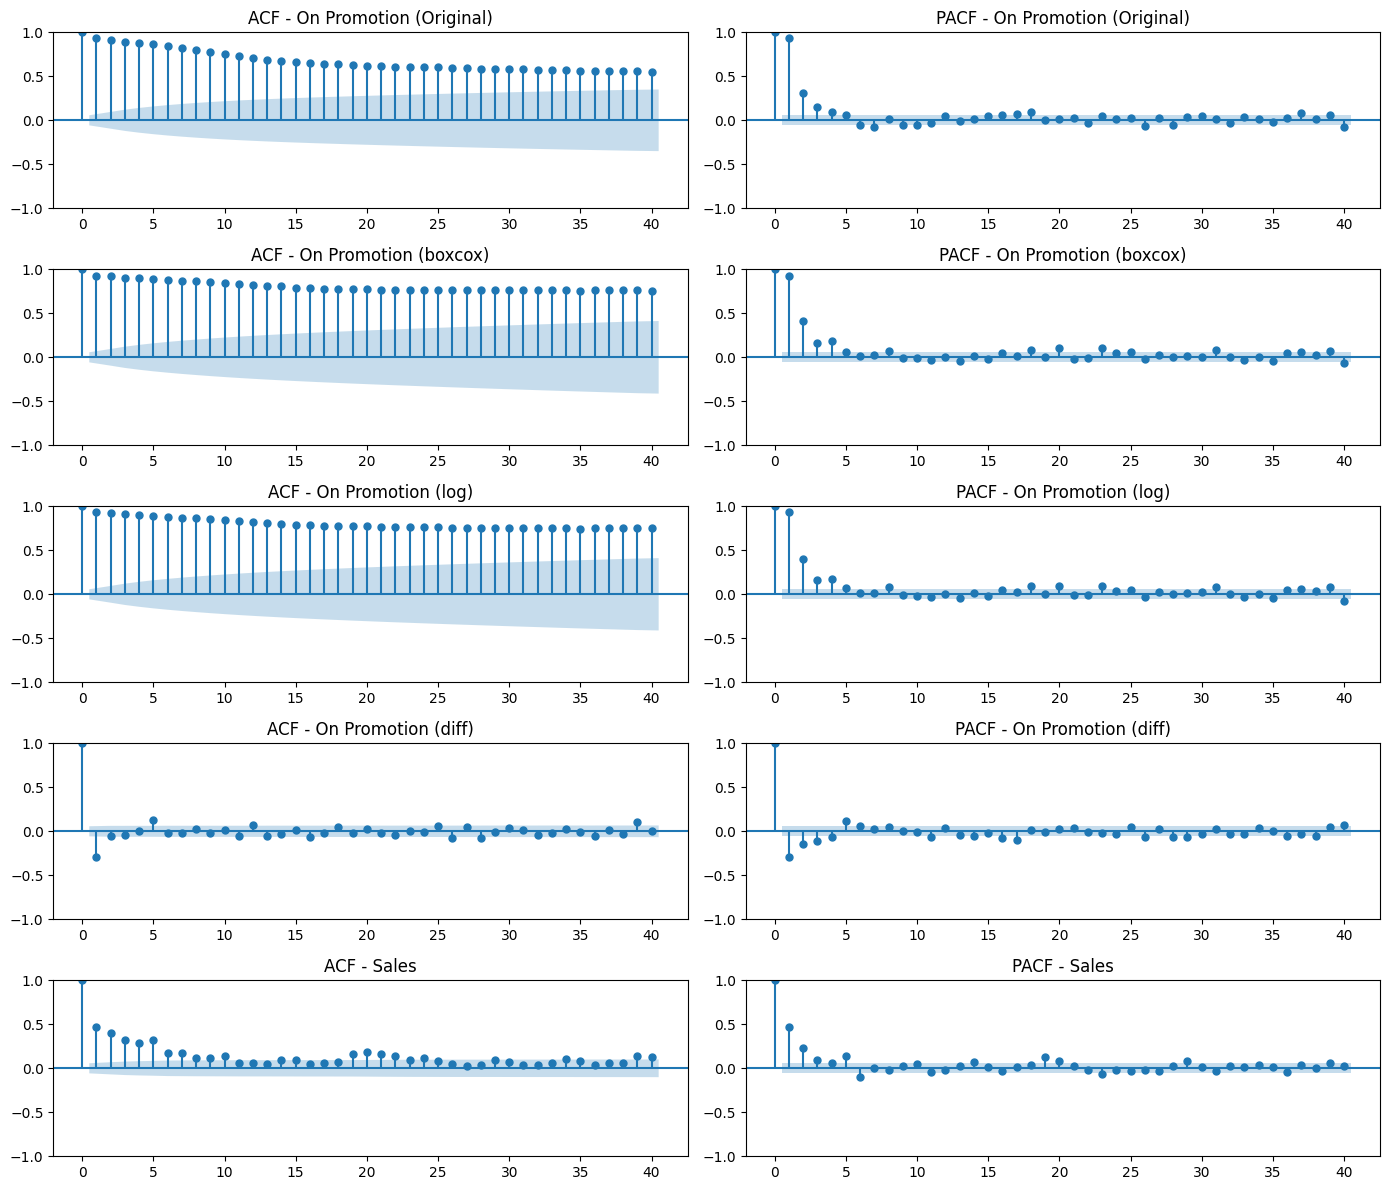

In [39]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Pastikan tanggal dalam format datetime
df_cleaning['date'] = pd.to_datetime(df_cleaning['date'])
df_cleaning.set_index('date', inplace=True)

# Drop NaN akibat differencing
df_cleaning.dropna(inplace=True)


fig, axes = plt.subplots(5, 2, figsize=(14, 12))

# ACF & PACF On Promotion (Original)
plot_acf(df_cleaning['onpromotion'], lags=40, ax=axes[0, 0])
axes[0, 0].set_title("ACF - On Promotion (Original)")

plot_pacf(df_cleaning['onpromotion'], lags=40, ax=axes[0, 1])
axes[0, 1].set_title("PACF - On Promotion (Original)")

# ACF & PACF On Promotion (Setelah box-cox)
plot_acf(df_cleaning['onpromotion_boxcox'], lags=40, ax=axes[1, 0])
axes[1, 0].set_title("ACF - On Promotion (boxcox)")

plot_pacf(df_cleaning['onpromotion_boxcox'], lags=40, ax=axes[1, 1])
axes[1, 1].set_title("PACF - On Promotion (boxcox)")

# ACF & PACF On Promotion (Setelah log)
plot_acf(df_cleaning['onpromotion_log'], lags=40, ax=axes[2, 0])
axes[2, 0].set_title("ACF - On Promotion (log)")

plot_pacf(df_cleaning['onpromotion_log'], lags=40, ax=axes[2, 1])
axes[2, 1].set_title("PACF - On Promotion (log)")

# ACF & PACF On Promotion (Setelah differencing)
plot_acf(df_cleaning['onpromotion_diff'], lags=40, ax=axes[3, 0])
axes[3, 0].set_title("ACF - On Promotion (diff)")

plot_pacf(df_cleaning['onpromotion_diff'], lags=40, ax=axes[3, 1])
axes[3, 1].set_title("PACF - On Promotion (diff)")

# ACF & PACF Sales
plot_acf(df_cleaning['sales'], lags=40, ax=axes[4, 0])
axes[4, 0].set_title("ACF - Sales")

plot_pacf(df_cleaning['sales'], lags=40, ax=axes[4, 1])
axes[4, 1].set_title("PACF - Sales")

plt.tight_layout()
plt.show()

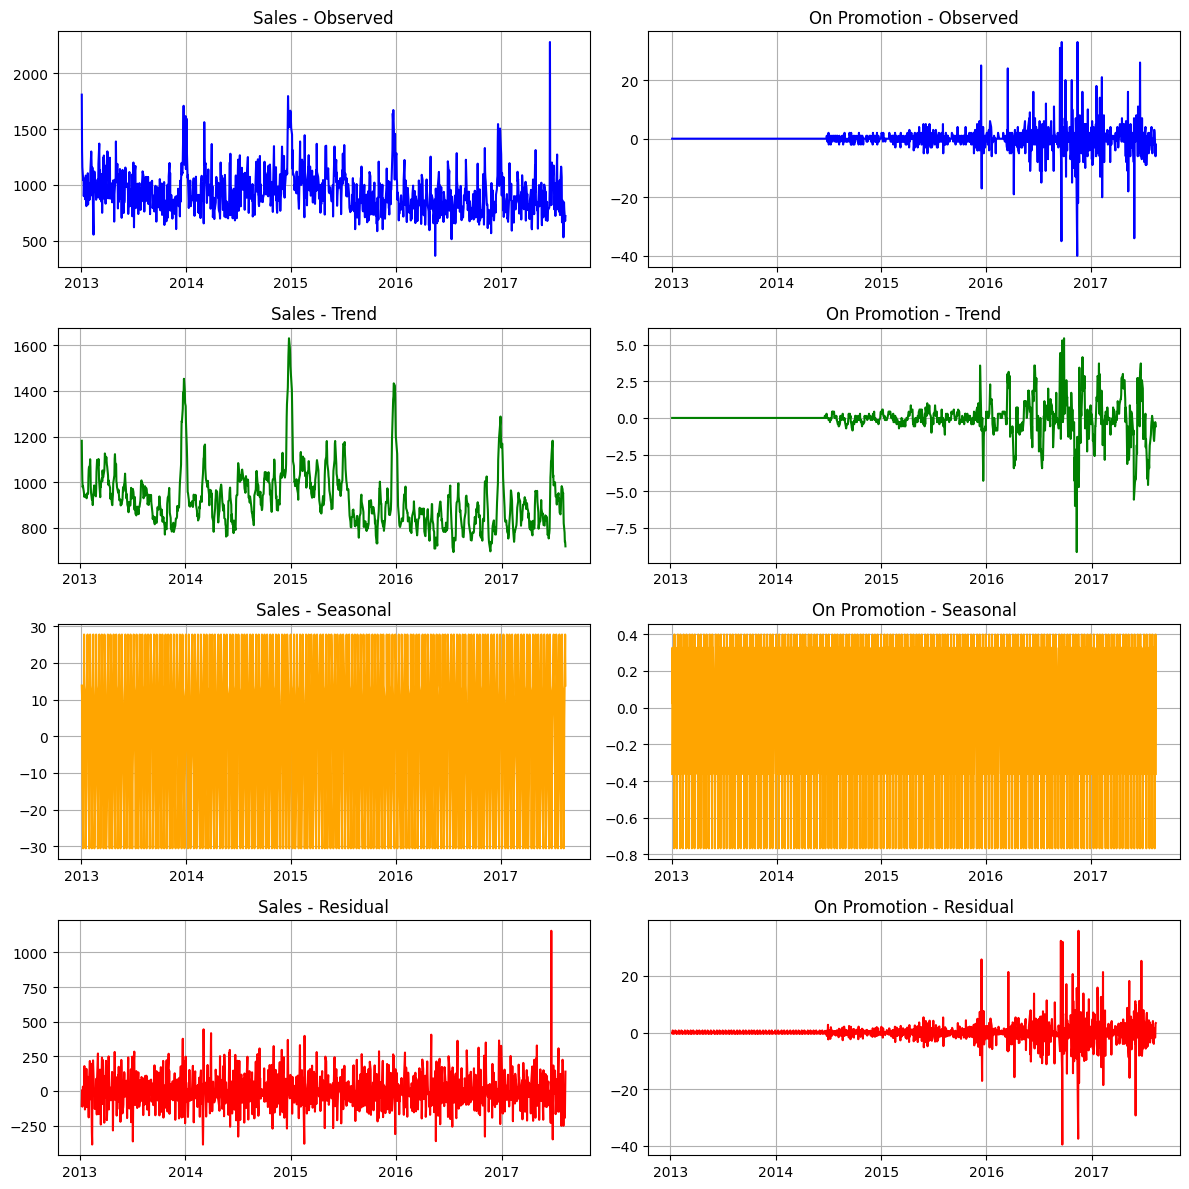

In [40]:
# uraikan data menjadi beberapa komponen dengan decompose untuk analisa lebih lanjut
from statsmodels.tsa.seasonal import seasonal_decompose

# Decompose Sales dan On Promotion
decomp_sales = seasonal_decompose(df_cleaning['sales'], model='additive', period=7)
decomp_onpromo = seasonal_decompose(df_cleaning['onpromotion_diff'], model='additive', period=7)

fig, axes = plt.subplots(4, 2, figsize=(12, 12))

# Warna untuk membedakan setiap plot
colors = ['blue', 'green', 'orange', 'red']

# Sales Decomposition
axes[0, 0].plot(decomp_sales.observed, color=colors[0])
axes[0, 0].set_title("Sales - Observed")
axes[1, 0].plot(decomp_sales.trend, color=colors[1])
axes[1, 0].set_title("Sales - Trend")
axes[2, 0].plot(decomp_sales.seasonal, color=colors[2])
axes[2, 0].set_title("Sales - Seasonal")
axes[3, 0].plot(decomp_sales.resid, color=colors[3])
axes[3, 0].set_title("Sales - Residual")

# On Promotion Decomposition
axes[0, 1].plot(decomp_onpromo.observed, color=colors[0])
axes[0, 1].set_title("On Promotion - Observed")
axes[1, 1].plot(decomp_onpromo.trend, color=colors[1])
axes[1, 1].set_title("On Promotion - Trend")
axes[2, 1].plot(decomp_onpromo.seasonal, color=colors[2])
axes[2, 1].set_title("On Promotion - Seasonal")
axes[3, 1].plot(decomp_onpromo.resid, color=colors[3])
axes[3, 1].set_title("On Promotion - Residual")

# Tambahkan grid untuk memperjelas pola
for ax in axes.flat:
    ax.grid(True)

plt.tight_layout()
plt.show()

In [41]:
# karna sepertinya ada pola seasonal disetiap bulan desember setiap tahunnya, lalu kita cek berdasarkan filter bulan december setiap tahunnya apakah ada pola yang sama di tanggal yang sama

In [42]:
df_december = df_cleaning[df_cleaning.index.month == 12]
years_to_filter = [2013, 2014, 2015, 2016]
df_filtered = df_december[df_december.index.year.isin(years_to_filter)]

In [43]:
december_daily_sales_filtered = df_filtered.groupby(df_filtered.index.day)['sales'].sum().reset_index()
december_daily_sales_filtered.columns = ['day', 'sales']

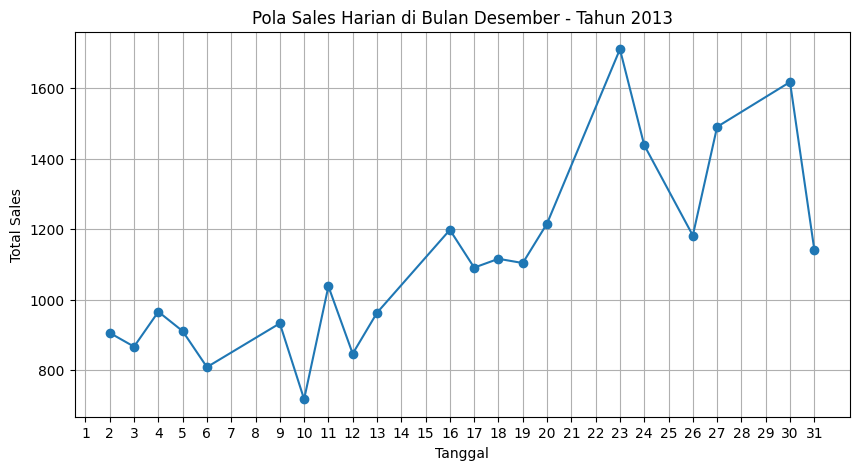

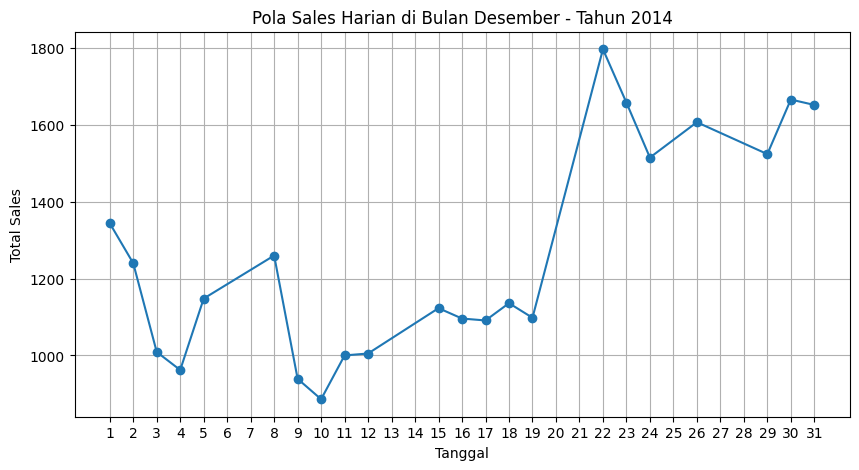

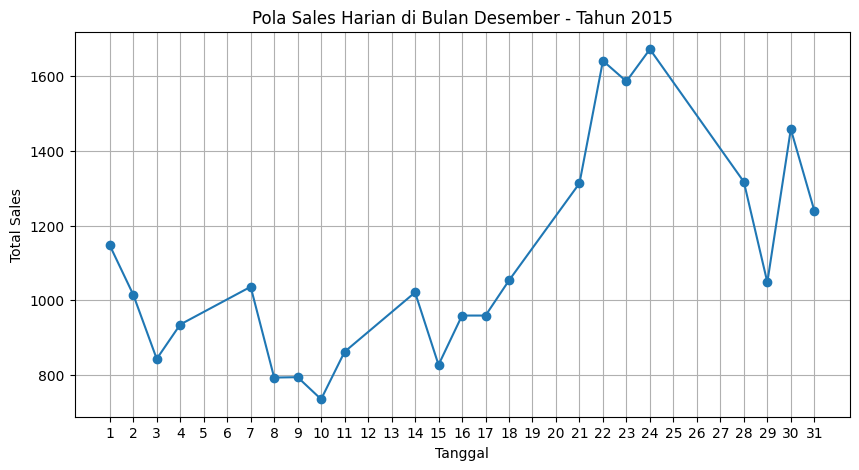

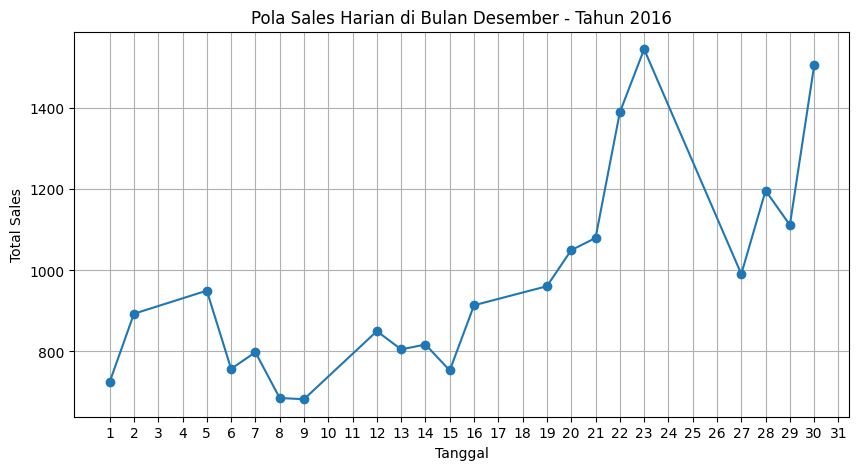

In [44]:
years = [2013, 2014, 2015, 2016]

for year in years:
    # Filter data untuk tahun yang sedang diproses
    data_for_year = df_filtered[df_filtered.index.year == year]

    # Group data berdasarkan tanggal dan hitung total sales harian
    daily_sales_for_year = data_for_year.groupby(data_for_year.index.day)['sales'].sum()

    # Buat plot
    plt.figure(figsize=(10, 5))
    plt.plot(daily_sales_for_year.index, daily_sales_for_year.values, marker='o')
    plt.title(f'Pola Sales Harian di Bulan Desember - Tahun {year}')
    plt.xlabel('Tanggal')
    plt.ylabel('Total Sales')
    plt.xticks(range(1, 32))
    plt.grid(True)
    plt.show()

In [45]:
# Setelah dicek dari plot december setiap tahunnya, tidak ada pola seasonal di tanggal yang sama

## Modelling Varmax based on RMSE

In [46]:
df_cleaning

,store_nbr,family,sales,onpromotion,dcoilwtico,dcoilwtico_interpolate_polynomial,onpromotion_boxcox,onpromotion_log,onpromotion_boxlog,onpromotion_diff
date,,,,,,,,,,
2013-01-02,5,CLEANING,1810.0,0,93.14,93.14,0.000000,0.000000,0.000000,0.0
2013-01-03,5,CLEANING,1305.0,0,92.97,92.97,0.000000,0.000000,0.000000,0.0
2013-01-04,5,CLEANING,1159.0,0,93.12,93.12,0.000000,0.000000,0.000000,0.0
2013-01-07,5,CLEANING,1043.0,0,93.20,93.20,0.000000,0.000000,0.000000,0.0
2013-01-08,5,CLEANING,1062.0,0,93.21,93.21,0.000000,0.000000,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...
2017-08-09,5,CLEANING,687.0,11,49.59,49.59,1.796335,2.484907,1.028310,3.0
2017-08-10,5,CLEANING,845.0,14,48.54,48.54,1.905055,2.708050,1.066452,3.0
2017-08-11,5,CLEANING,775.0,16,48.81,48.81,1.963158,2.833213,1.086256,2.0


In [47]:
from statsmodels.tsa.statespace.varmax import VARMAX
from sklearn.metrics import mean_squared_error

# Pisahkan variabel endogen dan eksogen
endog = df_cleaning[['sales', 'onpromotion_diff']]
exog = df_cleaning[['dcoilwtico_interpolate_polynomial']]

# Pisahkan data menjadi train dan test
train_size = int(len(df_cleaning) * 0.8)
#train_endog, test_endog = endog.iloc[:train_size], endog.iloc[train_size:]
#train_exog, test_exog = exog.iloc[:train_size], exog.iloc[train_size:]
train_endog, test_endog = endog[:train_size], endog[train_size:]
train_exog, test_exog = exog[:train_size], exog[train_size:]


In [48]:
train_endog

,sales,onpromotion_diff
date,,
2013-01-02,1810.0,0.0
2013-01-03,1305.0,0.0
2013-01-04,1159.0,0.0
2013-01-07,1043.0,0.0
2013-01-08,1062.0,0.0
...,...,...
2016-09-02,1226.0,0.0
2016-09-06,840.0,-2.0
2016-09-07,912.0,2.0


In [49]:
test_endog

,sales,onpromotion_diff
date,,
2016-09-12,940.0,-2.0
2016-09-13,763.0,-1.0
2016-09-14,731.0,1.0
2016-09-15,674.0,31.0
2016-09-16,854.0,4.0
...,...,...
2017-08-09,687.0,3.0
2017-08-10,845.0,3.0
2017-08-11,775.0,2.0


In [50]:
train_exog

,dcoilwtico_interpolate_polynomial
date,
2013-01-02,93.14
2013-01-03,92.97
2013-01-04,93.12
2013-01-07,93.20
2013-01-08,93.21
...,...
2016-09-02,44.39
2016-09-06,44.85
2016-09-07,45.47


In [51]:
import itertools
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.statespace.varmax import VARMAX
from sklearn.metrics import mean_squared_error

# Grid search untuk parameter p dan q
p_values = range(1, 5)  # Order autoregressive
q_values = range(0, 4)  # Order moving average
best_score = float("inf")
best_cfg = None
best_model = None

# Hitung rata-rata aktual untuk normalisasi
mean_sales = test_endog['sales'].mean()
std_promo = test_endog['onpromotion_diff'].std()

# Coba semua kombinasi (p, q)
for p, q in itertools.product(p_values, q_values):
    try:
        print(f"Evaluating VARMAX({p},{q})...")

        # Train model VARMAX
        model_varmax = VARMAX(train_endog, exog=train_exog, order=(p, q), trend='c')
        model_fit = model_varmax.fit(disp=False)

        # Forecast untuk data test
        preds = model_fit.forecast(steps=len(test_endog), exog=test_exog)

        # Kembalikan prediksi 'onpromotion' ke skala data awal
        preds['onpromotion'] = df_cleaning['onpromotion'].iloc[train_size - 1] + preds['onpromotion_diff'].cumsum()
        test_endog['onpromotion'] = df_cleaning['onpromotion'].iloc[train_size - 1] + test_endog['onpromotion_diff'].cumsum()

        # Pastikan nilai negatif tidak muncul karna onpromo harusnya tidak ada yang negatif
        preds['onpromotion'] = preds['onpromotion'].clip(lower=0)
        test_endog['onpromotion'] = test_endog['onpromotion'].clip(lower=0)

        # Hitung RMSE
        rmse_sales = np.sqrt(mean_squared_error(test_endog['sales'], preds['sales']))
        rmse_promo = np.sqrt(mean_squared_error(test_endog['onpromotion'], preds['onpromotion']))

        # Normalisasi RMSE
        rmse_sales_norm = rmse_sales / mean_sales
        rmse_promo_norm = rmse_promo / std_promo
        total_score = rmse_sales_norm + rmse_promo_norm

        print(f"VARMAX({p},{q}) - Normalized RMSE: {total_score:.4f}")

        # Simpan model dengan skor terbaik
        if total_score < best_score:
            best_score = total_score
            best_cfg = (p, q)
            best_model = model_fit

    except Exception as e:
        print(f"VARMAX({p},{q}) gagal dilatih: {e}")

print(f"\nBest VARMAX order: {best_cfg} dengan Normalized RMSE: {best_score:.4f}")



Evaluating VARMAX(1,0)...


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
<ipython-input-51-5a9a987f204b>:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pa

VARMAX(1,0) - Normalized RMSE: 2.3765
Evaluating VARMAX(1,1)...


/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/varmax.py:160: EstimationWarning: Estimation of VARMA(p,q) models is not generically robust, due especially to identification issues.
  warn('Estimation of VARMA(p,q) models is not generically robust,'
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local

VARMAX(1,1) - Normalized RMSE: 2.5090
Evaluating VARMAX(1,2)...


...

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/varmax.py:160: EstimationWarning: Estimation of VARMA(p,q) models is not generically robust, due especially to identification issues.
  warn('Estimation of VARMA(p,q) models is not generically robust,'
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/varmax.py:160: EstimationWarning: Estimation of VARMA(p,q) models is not generically robust, due especially to identification issues.
  warn('Estimation of VARMA(p,q

VARMAX(4,1) - Normalized RMSE: 2.3156
Evaluating VARMAX(4,2)...


/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/varmax.py:160: EstimationWarning: Estimation of VARMA(p,q) models is not generically robust, due especially to identification issues.
  warn('Estimation of VARMA(p,q) models is not generically robust,'
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local

VARMAX(4,2) - Normalized RMSE: 2.3063
Evaluating VARMAX(4,3)...
VARMAX(4,3) - Normalized RMSE: 2.3026

Best VARMAX order: (3, 3) dengan Normalized RMSE: 2.1953


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/varmax.py:160: EstimationWarning: Estimation of VARMA(p,q) models is not generically robust, due especially to identification issues.
  warn('Estimation of VARMA(p,q) models is not generically robust,'
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/varmax.py:160: EstimationWarning: Estimation of VARMA(p,q) models is not generically robust, due especially to identification issues.
  warn('Estimation of VARMA(p,q

In [52]:
# Gunakan model terbaik untuk prediksi
test_preds1 = best_model.forecast(steps=len(test_endog), exog=test_exog)

# Inverse differencing untuk onpromotion
test_preds1['onpromotion'] = df_cleaning['onpromotion'].iloc[train_size - 1] + test_preds1['onpromotion_diff'].cumsum()
test_preds1['onpromotion'] = test_preds1['onpromotion'].clip(lower=0)

test_preds1

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/varmax.py:160: EstimationWarning: Estimation of VARMA(p,q) models is not generically robust, due especially to identification issues.
  warn('Estimation of VARMA(p,q) models is not generically robust,'
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/varmax.py:160: EstimationWarning: Estimation of VARMA(p,q) models is not generically robust, due especially to identification issues.
  warn('Estimation of VARMA(p,q

,sales,onpromotion_diff,onpromotion
930,839.305812,0.895486,4.895486
931,863.340519,0.101338,4.996825
932,880.523253,0.175052,5.171876
933,883.256908,0.098036,5.269912
934,893.793839,0.060777,5.330689
...,...,...,...
1158,929.442380,0.031234,12.588952
1159,929.301834,0.032564,12.621516
1160,929.317102,0.031921,12.653437
1161,929.108884,0.033281,12.686718


In [53]:
# Hitung RMSE dari prediksi terbaik
final_rmse_sales = np.sqrt(mean_squared_error(test_endog['sales'], test_preds1['sales']))
final_rmse_promo = np.sqrt(mean_squared_error(test_endog['onpromotion'], test_preds1['onpromotion']))

print(f"Final RMSE Sales: {final_rmse_sales:.4f}")
print(f"Final RMSE Onpromotion: {final_rmse_promo:.4f}")

Final RMSE Sales: 195.3944
Final RMSE Onpromotion: 16.4868


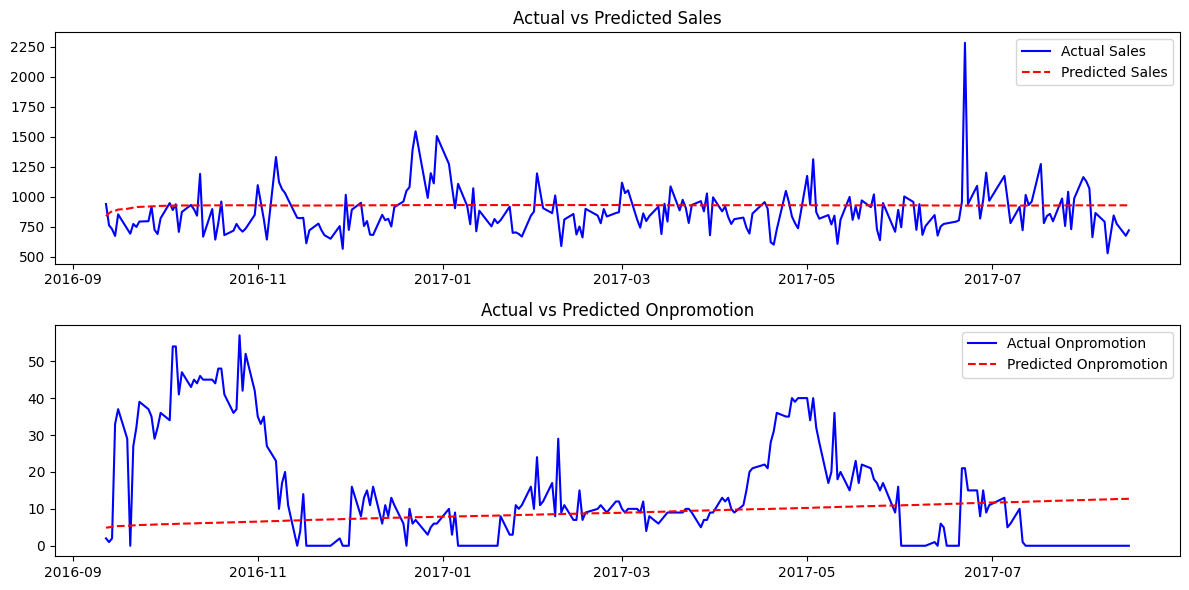

In [54]:
# Plot hasil prediksi vs actual
plt.figure(figsize=(12, 6))

# Plot Sales
plt.subplot(2, 1, 1)
plt.plot(test_endog.index, test_endog['sales'], label='Actual Sales', color='blue')
plt.plot(test_endog.index, test_preds1['sales'], label='Predicted Sales', color='red', linestyle='dashed')
plt.title('Actual vs Predicted Sales')
plt.legend()

# Plot Onpromotion (sudah dalam skala asli)
plt.subplot(2, 1, 2)
plt.plot(test_endog.index, test_endog['onpromotion'], label='Actual Onpromotion', color='blue')
plt.plot(test_endog.index, test_preds1['onpromotion'], label='Predicted Onpromotion', color='red', linestyle='dashed')
plt.title('Actual vs Predicted Onpromotion')
plt.legend()

plt.tight_layout()
plt.show()

In [55]:
test_preds1

,sales,onpromotion_diff,onpromotion
930,839.305812,0.895486,4.895486
931,863.340519,0.101338,4.996825
932,880.523253,0.175052,5.171876
933,883.256908,0.098036,5.269912
934,893.793839,0.060777,5.330689
...,...,...,...
1158,929.442380,0.031234,12.588952
1159,929.301834,0.032564,12.621516
1160,929.317102,0.031921,12.653437
1161,929.108884,0.033281,12.686718


## Modelling Using Single Layer LSTM

In [56]:
!pip install tensorflow==2.18.0

In [57]:
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import time
from sklearn.metrics import mean_squared_error

# Set kolom tanggal sebagai indeks
df_cleaning_original.set_index('date', inplace=True)

# Preprocessing mengubah data rentang 0 - 1
scaler_endog = MinMaxScaler()
scaler_exog = MinMaxScaler()

# Pisahkan variabel endogen dan eksogen
endog_ori = df_cleaning_original[['sales', 'onpromotion']]
exog_ori = df_cleaning_original[['dcoilwtico_interpolate_polynomial']]

# Pisahkan data menjadi train dan test
train_size = int(len(df_cleaning_original) * 0.8)
train_endog, test_endog = endog.iloc[:train_size], endog.iloc[train_size:]
train_exog, test_exog = exog.iloc[:train_size], exog.iloc[train_size:]

# Scaling the data (already done earlier)
endog_scaled = scaler_endog.fit_transform(endog_ori)
exog_scaled = scaler_exog.fit_transform(exog_ori)

In [58]:
# Check the shape of the endog_scaled (should have 2 columns)
print(f"endog_scaled shape: {endog_scaled.shape}")

endog_scaled shape: (1688, 2)


In [59]:
# Ensure endog_scaled has 2 columns (sales and onpromotion)
print(f"endog_scaled shape: {endog_scaled.shape}")  # (1688, 2)

# Combine exogenous (exog) and endogenous (endog) features into x
x = np.concatenate([exog_scaled, endog_scaled], axis=1)

# The target variable 'y' is the endog_scaled
y = endog_scaled  # 'sales' and 'onpromotion' as the target (2 columns)

endog_scaled shape: (1688, 2)


In [60]:
def load_data(X, seq_len, train_size=0.8):
    amount_of_features = X.shape[1]
    X_mat = X
    sequence_length = seq_len + 1
    data = []

    for index in range(len(X_mat) - sequence_length):
        data.append(X_mat[index: index + sequence_length])

    data = np.array(data)
    train_split = int(round(train_size * data.shape[0]))
    train_data = data[:train_split, :]

    x_train = train_data[:, :-1]
    y_train = train_data[:, -1, 1:]  # Select only the last 2 columns (sales and onpromotion)

    x_test = data[train_split:, :-1]
    y_test = data[train_split:, -1, 1:]  # Select only the last 2 columns (sales and onpromotion)

    # Check shapes before reshaping
    print(f"x_train shape (before reshape): {x_train.shape}")
    print(f"y_train shape (before reshape): {y_train.shape}")

    # Make sure y_train and y_test have 2 columns (for 'sales' and 'onpromotion')
    assert y_train.shape[1] == 2, "y_train should have 2 columns (sales and onpromotion)"
    assert y_test.shape[1] == 2, "y_test should have 2 columns (sales and onpromotion)"

    # Reshape x_train and x_test to 3D arrays for LSTM input
    x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], amount_of_features))
    x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], amount_of_features))

    return x_train, y_train, x_test, y_test

# Setting window size
window = 22 # data historis
X_train, y_train, X_test, y_test = load_data(x, window)

# Print the shapes of data after loading and reshaping
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

x_train shape (before reshape): (1332, 22, 3)
y_train shape (before reshape): (1332, 2)
X_train shape: (1332, 22, 3), y_train shape: (1332, 2)
X_test shape: (333, 22, 3), y_test shape: (333, 2)


In [61]:
# LSTM Model
model1 = Sequential()
model1.add(LSTM(units=50, input_shape=(window, X_train.shape[2])))
model1.add(Dropout(0.2))

# Output layer with 2 units for 'sales' and 'onpromotion'
model1.add(Dense(units=50, kernel_initializer='uniform', activation='tanh'))
model1.add(Dense(units=2, kernel_initializer='uniform', activation='linear'))  # Two outputs

# Compile the model
model1.compile(optimizer='adam', loss='mean_squared_error')

# Fit the model
start = time.time()
history = model1.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.05, verbose=1)
print('Compilation time: ', time.time() - start)

Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


40/40 ━━━━━━━━━━━━━━━━━━━━ 7s 48ms/step - loss: 0.0641 - val_loss: 0.0112
Epoch 2/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0100 - val_loss: 0.0100
Epoch 3/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - loss: 0.0087 - val_loss: 0.0104
Epoch 4/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 0.0081 - val_loss: 0.0086
Epoch 5/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0066 - val_loss: 0.0073
Epoch 6/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.0070 - val_loss: 0.0078
Epoch 7/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - loss: 0.0068 - val_loss: 0.0083
Epoch 8/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.0064 - val_loss: 0.0084
Epoch 9/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 0.0061 - val_loss: 0.0079
Epoch 10/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - loss: 0.0065 - val_loss: 0.0081
Epoch 11/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0062 - val_loss: 0.0078
Epoch 12/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.0

In [62]:
# Predictions
trainPredict = model1.predict(X_train)
testPredict = model1.predict(X_test)

# Inverse transform to get the actual values
trainPredict = scaler_endog.inverse_transform(trainPredict)
trainY = scaler_endog.inverse_transform(y_train)
testPredict = scaler_endog.inverse_transform(testPredict)
testY = scaler_endog.inverse_transform(y_test)

# Plotting
plot_predicted_sales = testPredict[:, 0].reshape(-1, 1)
plot_predicted_onpromotion = testPredict[:, 1].reshape(-1, 1)

plot_actual_sales = testY[:, 0].reshape(-1, 1)
plot_actual_onpromotion = testY[:, 1].reshape(-1, 1)

42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


In [63]:
# Print shapes for verification
print(f"Plot actual sales shape: {plot_actual_sales.shape}")
print(f"Plot predicted sales shape: {plot_predicted_sales.shape}")

Plot actual sales shape: (333, 1)
Plot predicted sales shape: (333, 1)


In [64]:
# Calculate RMSE for both sales and onpromotion

trainScore_sales = mean_squared_error(trainY[:, 0], trainPredict[:, 0]) ** 0.5
testScore_sales = mean_squared_error(testY[:, 0], testPredict[:, 0]) ** 0.5

trainScore_onpromotion = mean_squared_error(trainY[:, 1], trainPredict[:, 1]) ** 0.5
testScore_onpromotion = mean_squared_error(testY[:, 1], testPredict[:, 1]) ** 0.5


In [65]:
print(f'Train Score for sales: {trainScore_sales:.2f} RMSE')
print(f'Test Score for sales: {testScore_sales:.2f} RMSE')

print(f'Train Score for onpromotion: {trainScore_onpromotion:.2f} RMSE')
print(f'Test Score for onpromotion: {testScore_onpromotion:.2f} RMSE')

Train Score for sales: 192.97 RMSE
Test Score for sales: 220.63 RMSE
Train Score for onpromotion: 2.17 RMSE
Test Score for onpromotion: 7.53 RMSE


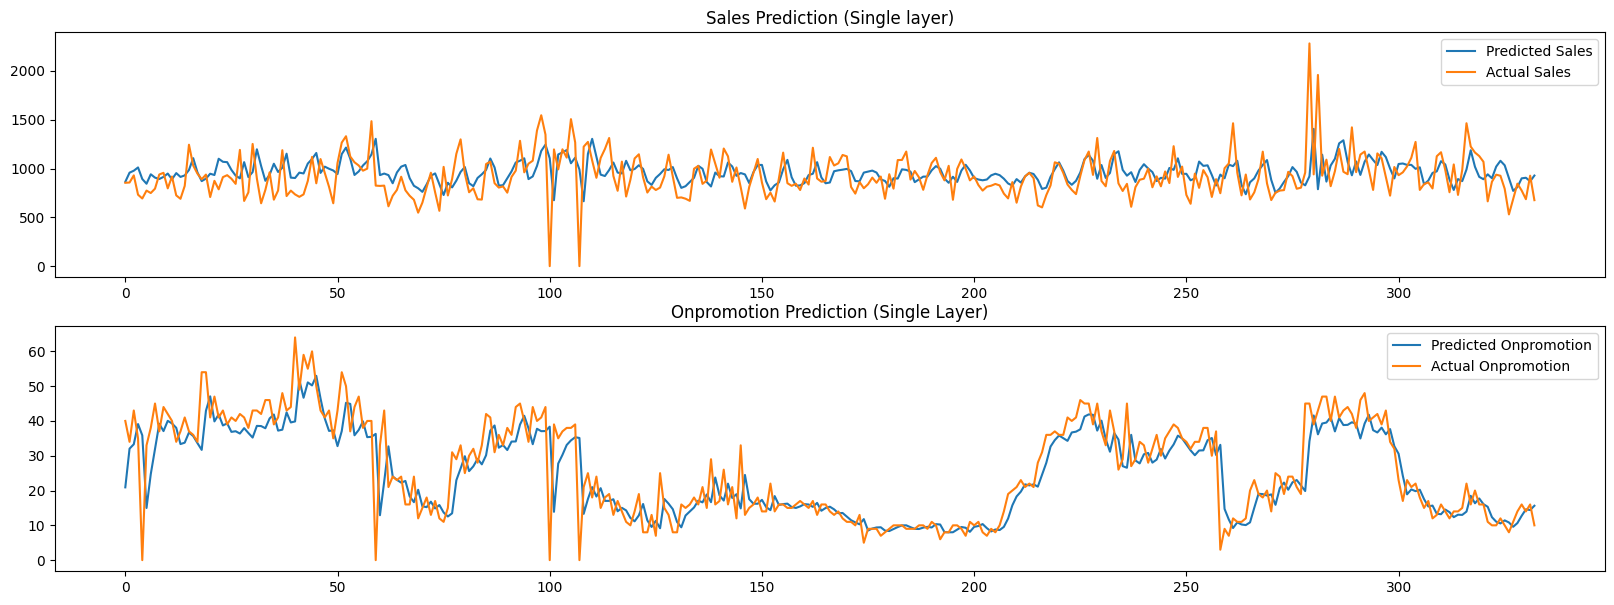

In [66]:
# Plot the results for both targets
plt.figure(figsize=(20, 7))

# Sales plot
plt.subplot(2, 1, 1)
plt.plot(pd.DataFrame(plot_predicted_sales), label='Predicted Sales')
plt.plot(pd.DataFrame(plot_actual_sales), label='Actual Sales')
plt.legend(loc='best')
plt.title('Sales Prediction (Single layer)')

# Onpromotion plot
plt.subplot(2, 1, 2)
plt.plot(pd.DataFrame(plot_predicted_onpromotion), label='Predicted Onpromotion')
plt.plot(pd.DataFrame(plot_actual_onpromotion), label='Actual Onpromotion')
plt.legend(loc='best')
plt.title('Onpromotion Prediction (Single Layer)')

plt.show()

## Modelling Using Stacked LSTM Using Dropout

In [67]:
from tensorflow.keras.callbacks import EarlyStopping

# Stacked LSTM Model with Dropout
model2 = Sequential()

# First LSTM layer
model2.add(LSTM(units=50, return_sequences=True, input_shape=(window, X_train.shape[2])))
model2.add(Dropout(0.2))

# Second LSTM layer
model2.add(LSTM(units=50, return_sequences=True))
model2.add(Dropout(0.2))

# Third LSTM layer
model2.add(LSTM(units=50))
model2.add(Dropout(0.2))

# Dense layers
model2.add(Dense(units=50, kernel_initializer='uniform', activation='tanh'))
model2.add(Dense(units=2, kernel_initializer='uniform', activation='linear'))  # Two outputs (sales and onpromotion)

earlystop2 = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=50)

# Compile the model
model2.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
start = time.time()
history2 = model2.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.05, verbose=1, callbacks=[earlystop2])
print('Training time: ', time.time() - start)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 22s 139ms/step - loss: 0.0586 - val_loss: 0.0169
Epoch 2/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 101ms/step - loss: 0.0099 - val_loss: 0.0125
Epoch 3/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 86ms/step - loss: 0.0081 - val_loss: 0.0097
Epoch 4/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 78ms/step - loss: 0.0083 - val_loss: 0.0066
Epoch 5/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - loss: 0.0075 - val_loss: 0.0061
Epoch 6/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 0.0071 - val_loss: 0.0078
Epoch 7/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - loss: 0.0074 - val_loss: 0.0114
Epoch 8/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - loss: 0.0070 - val_loss: 0.0088
Epoch 9/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - loss: 0.0065 - val_loss: 0.0076
Epoch 10/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - loss: 0.0065 - val_loss: 0.0177
Epoch 11/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 0.0073 - val_loss: 0.0078
Epoch 12/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/s

In [68]:
# Predictions
trainPredict2 = model2.predict(X_train)
testPredict2 = model2.predict(X_test)

# Inverse transform to get actual values
trainPredict2 = scaler_endog.inverse_transform(trainPredict2)
trainY2 = scaler_endog.inverse_transform(y_train)
testPredict2 = scaler_endog.inverse_transform(testPredict2)
testY2 = scaler_endog.inverse_transform(y_test)

42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


In [69]:
# Calculate RMSE for both sales and onpromotion
trainScore_sales2 = mean_squared_error(trainY2[:, 0], trainPredict2[:, 0]) ** 0.5
testScore_sales2 = mean_squared_error(testY2[:, 0], testPredict2[:, 0]) ** 0.5

trainScore_onpromotion2 = mean_squared_error(trainY2[:, 1], trainPredict2[:, 1]) ** 0.5
testScore_onpromotion2 = mean_squared_error(testY2[:, 1], testPredict2[:, 1]) ** 0.5

In [70]:
print(f'Train Score for sales: {trainScore_sales2:.2f} RMSE')
print(f'Test Score for sales: {testScore_sales2:.2f} RMSE')

print(f'Train Score for onpromotion: {trainScore_onpromotion2:.2f} RMSE')
print(f'Test Score for onpromotion: {testScore_onpromotion2:.2f} RMSE')

Train Score for sales: 218.82 RMSE
Test Score for sales: 226.98 RMSE
Train Score for onpromotion: 2.22 RMSE
Test Score for onpromotion: 13.06 RMSE


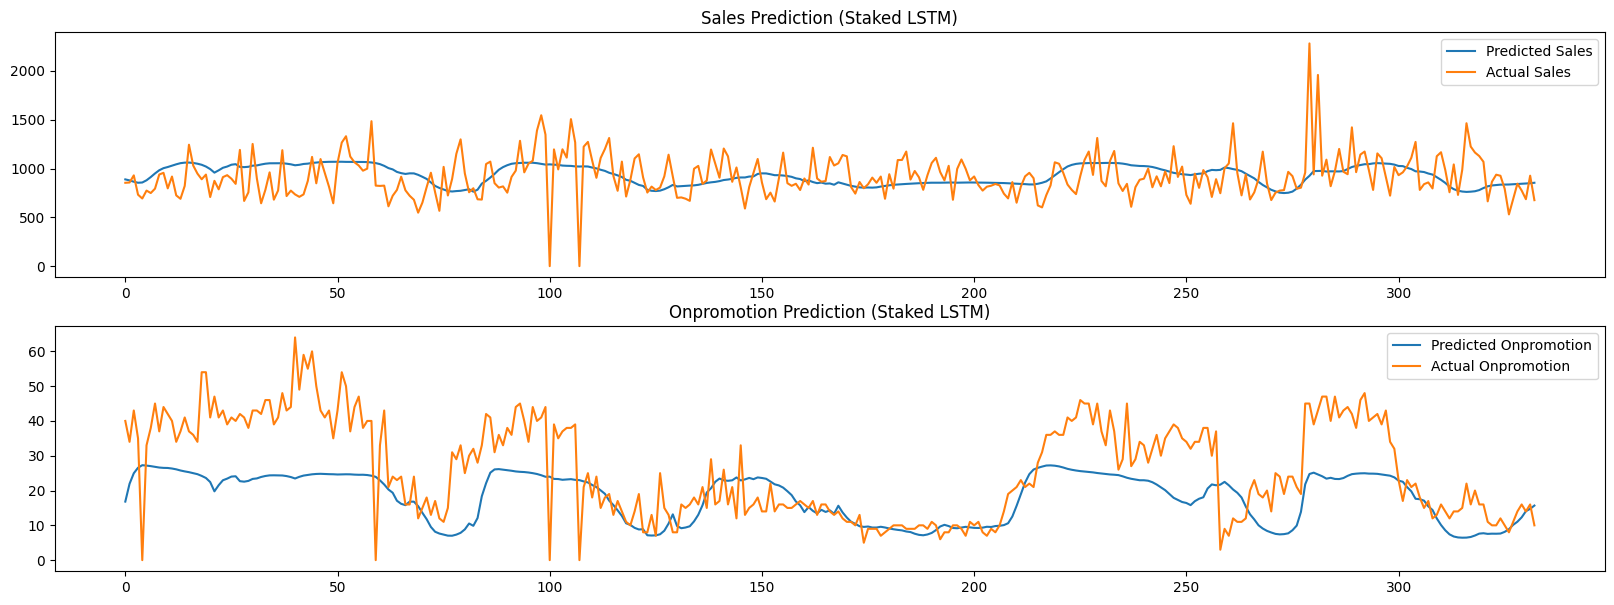

In [71]:
# Plot the results
plt.figure(figsize=(20, 7))

# Sales plot
plt.subplot(2, 1, 1)
plt.plot(pd.DataFrame(testPredict2[:, 0]), label='Predicted Sales')
plt.plot(pd.DataFrame(testY2[:, 0]), label='Actual Sales')
plt.legend(loc='best')
plt.title('Sales Prediction (Staked LSTM)')

# Onpromotion plot
plt.subplot(2, 1, 2)
plt.plot(pd.DataFrame(testPredict2[:, 1]), label='Predicted Onpromotion')
plt.plot(pd.DataFrame(testY2[:, 1]), label='Actual Onpromotion')
plt.legend(loc='best')
plt.title('Onpromotion Prediction (Staked LSTM)')

plt.show()

## Modelling Using Single layer LSTM and Bidirectional

In [72]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Bidirectional

# Single Layer with Bidirectional LSTM Model
model3 = Sequential()
model3.add(Bidirectional(LSTM(units=50, input_shape=(window, X_train.shape[2]))))
model3.add(Dropout(0.2))

# Dense layer with 2 units for 'sales' and 'onpromotion'
model3.add(Dense(units=50, kernel_initializer='uniform', activation='tanh'))
model3.add(Dense(units=2, kernel_initializer='uniform', activation='linear'))  # Two outputs (sales and onpromo)

earlystop3 = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=50)

# Compile the model
model3.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
start = time.time()
history3 = model3.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.05, verbose=1, callbacks=[earlystop3])
print('Compilation time: ', time.time() - start)

Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


40/40 ━━━━━━━━━━━━━━━━━━━━ 8s 53ms/step - loss: 0.0568 - val_loss: 0.0128
Epoch 2/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0093 - val_loss: 0.0119
Epoch 3/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0076 - val_loss: 0.0084
Epoch 4/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0074 - val_loss: 0.0088
Epoch 5/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0065 - val_loss: 0.0109
Epoch 6/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0066 - val_loss: 0.0079
Epoch 7/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0058 - val_loss: 0.0087
Epoch 8/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0067 - val_loss: 0.0076
Epoch 9/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0056 - val_loss: 0.0079
Epoch 10/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0052 - val_loss: 0.0064
Epoch 11/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0062 - val_loss: 0.0074
Epoch 12/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.0

In [73]:
# Predictions
trainPredict3 = model3.predict(X_train)
testPredict3 = model3.predict(X_test)

# Inverse transform to get actual values
trainPredict3 = scaler_endog.inverse_transform(trainPredict3)
trainY3 = scaler_endog.inverse_transform(y_train)
testPredict3 = scaler_endog.inverse_transform(testPredict3)
testY3 = scaler_endog.inverse_transform(y_test)

42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


In [74]:
# Calculate RMSE for both sales and onpromotion
trainScore_sales3 = mean_squared_error(trainY3[:, 0], trainPredict3[:, 0]) ** 0.5
testScore_sales3 = mean_squared_error(testY3[:, 0], testPredict3[:, 0]) ** 0.5

trainScore_onpromotion3 = mean_squared_error(trainY3[:, 1], trainPredict3[:, 1]) ** 0.5
testScore_onpromotion3 = mean_squared_error(testY3[:, 1], testPredict3[:, 1]) ** 0.5

In [75]:
print(f'Train Score for sales: {trainScore_sales3:.2f} RMSE')
print(f'Test Score for sales: {testScore_sales3:.2f} RMSE')

print(f'Train Score for onpromotion: {trainScore_onpromotion3:.2f} RMSE')
print(f'Test Score for onpromotion: {testScore_onpromotion3:.2f} RMSE')

Train Score for sales: 179.07 RMSE
Test Score for sales: 215.25 RMSE
Train Score for onpromotion: 2.23 RMSE
Test Score for onpromotion: 8.19 RMSE


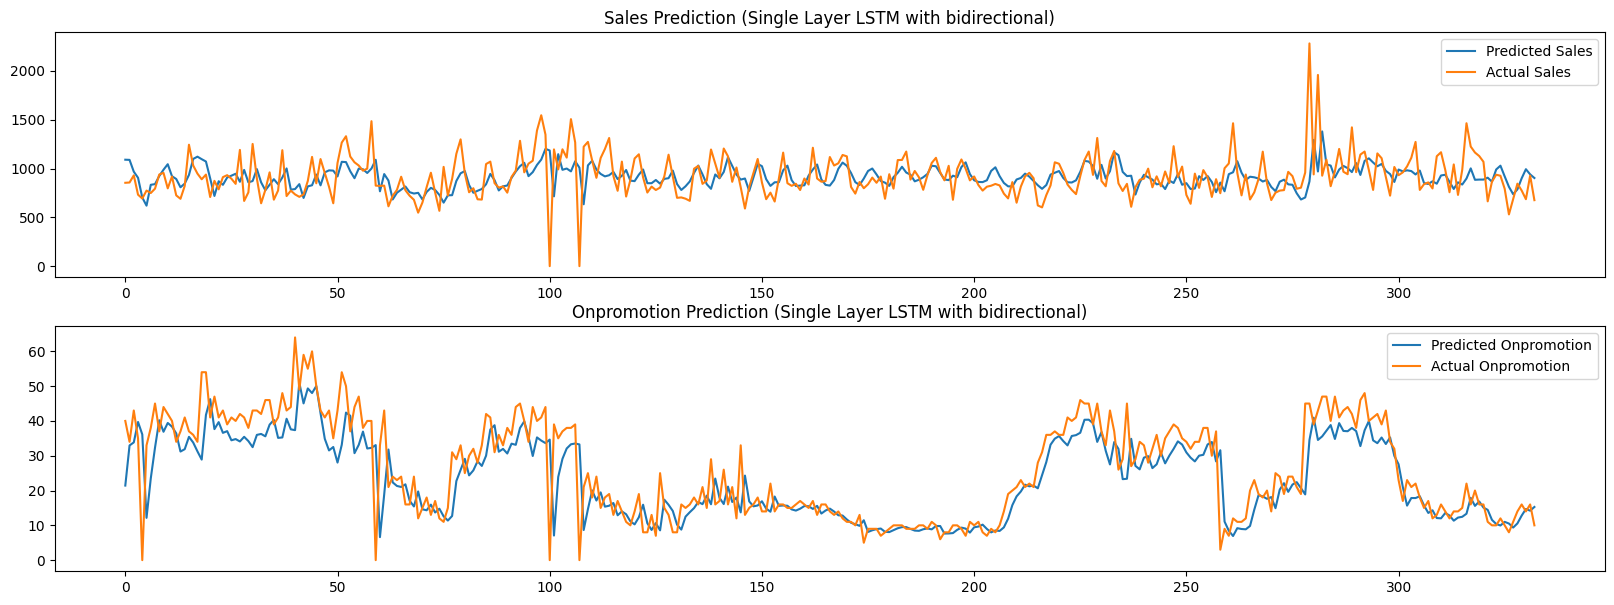

In [76]:
# Plot the results
plt.figure(figsize=(20, 7))

# Sales plot
plt.subplot(2, 1, 1)
plt.plot(pd.DataFrame(testPredict3[:, 0]), label='Predicted Sales')
plt.plot(pd.DataFrame(testY3[:, 0]), label='Actual Sales')
plt.legend(loc='best')
plt.title('Sales Prediction (Single Layer LSTM with bidirectional)')

# Onpromotion plot
plt.subplot(2, 1, 2)
plt.plot(pd.DataFrame(testPredict3[:, 1]), label='Predicted Onpromotion')
plt.plot(pd.DataFrame(testY3[:, 1]), label='Actual Onpromotion')
plt.legend(loc='best')
plt.title('Onpromotion Prediction (Single Layer LSTM with bidirectional)')

plt.show()

## Modelling Using Stacked LSTM using dropout and bidirectional

In [77]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Bidirectional

# Stacked LSTM Model with Dropout
model4 = Sequential()

# First LSTM layer
model4.add(Bidirectional(LSTM(units=50, return_sequences=True, input_shape=(window, X_train.shape[2]))))
model4.add(Dropout(0.2))

# Second LSTM layer
model4.add(Bidirectional(LSTM(units=50, return_sequences=True)))
model4.add(Dropout(0.2))

# Third LSTM layer
model4.add(Bidirectional(LSTM(units=50)))
model4.add(Dropout(0.2))

# Dense layers
model4.add(Dense(units=50, kernel_initializer='uniform', activation='tanh'))
model4.add(Dense(units=2, kernel_initializer='uniform', activation='linear'))  # Two outputs (sales and onpromotion)

earlystop4 = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=50)

# Compile the model
model4.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
start = time.time()
history4 = model4.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.05, verbose=1, callbacks=[earlystop4])
print('Training time: ', time.time() - start)

Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


40/40 ━━━━━━━━━━━━━━━━━━━━ 19s 125ms/step - loss: 0.0491 - val_loss: 0.0111
Epoch 2/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step - loss: 0.0081 - val_loss: 0.0077
Epoch 3/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step - loss: 0.0077 - val_loss: 0.0086
Epoch 4/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - loss: 0.0068 - val_loss: 0.0106
Epoch 5/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step - loss: 0.0065 - val_loss: 0.0106
Epoch 6/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step - loss: 0.0059 - val_loss: 0.0138
Epoch 7/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step - loss: 0.0060 - val_loss: 0.0097
Epoch 8/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 99ms/step - loss: 0.0063 - val_loss: 0.0082
Epoch 9/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step - loss: 0.0056 - val_loss: 0.0076
Epoch 10/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step - loss: 0.0055 - val_loss: 0.0085
Epoch 11/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step - loss: 0.0059 - val_loss: 0.0072
Epoch 12/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 92ms/step - loss: 0

In [78]:
# Predictions
trainPredict4 = model4.predict(X_train)
testPredict4 = model4.predict(X_test)

# Inverse transform to get actual values
trainPredict4 = scaler_endog.inverse_transform(trainPredict4)
trainY4 = scaler_endog.inverse_transform(y_train)
testPredict4 = scaler_endog.inverse_transform(testPredict4)
testY4 = scaler_endog.inverse_transform(y_test)

42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


In [79]:
# Calculate RMSE for both sales and onpromotion
trainScore_sales4 = mean_squared_error(trainY4[:, 0], trainPredict4[:, 0]) ** 0.5
testScore_sales4 = mean_squared_error(testY4[:, 0], testPredict4[:, 0]) ** 0.5

trainScore_onpromotion4 = mean_squared_error(trainY4[:, 1], trainPredict4[:, 1]) ** 0.5
testScore_onpromotion4 = mean_squared_error(testY4[:, 1], testPredict4[:, 1]) ** 0.5

In [80]:
print(f'Train Score for sales: {trainScore_sales4:.2f} RMSE')
print(f'Test Score for sales: {testScore_sales4:.2f} RMSE')

print(f'Train Score for onpromotion: {trainScore_onpromotion4:.2f} RMSE')
print(f'Test Score for onpromotion: {testScore_onpromotion4:.2f} RMSE')

Train Score for sales: 210.19 RMSE
Test Score for sales: 216.98 RMSE
Train Score for onpromotion: 2.17 RMSE
Test Score for onpromotion: 12.38 RMSE


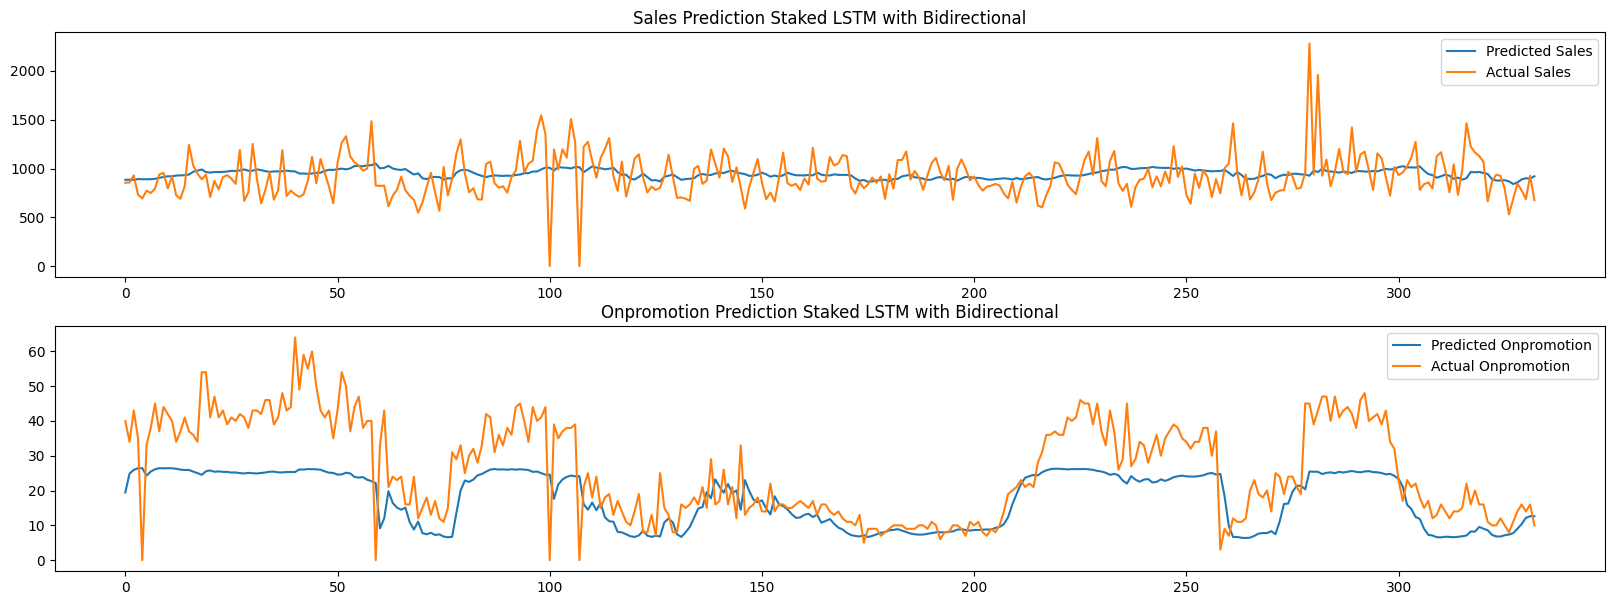

In [81]:
# Plot the results
plt.figure(figsize=(20, 7))

# Sales plot
plt.subplot(2, 1, 1)
plt.plot(pd.DataFrame(testPredict4[:, 0]), label='Predicted Sales')
plt.plot(pd.DataFrame(testY4[:, 0]), label='Actual Sales')
plt.legend(loc='best')
plt.title('Sales Prediction Staked LSTM with Bidirectional')

# Onpromotion plot
plt.subplot(2, 1, 2)
plt.plot(pd.DataFrame(testPredict4[:, 1]), label='Predicted Onpromotion')
plt.plot(pd.DataFrame(testY4[:, 1]), label='Actual Onpromotion')
plt.legend(loc='best')
plt.title('Onpromotion Prediction Staked LSTM with Bidirectional')

plt.show()

## Evaluation Model

In [82]:
rmse_comparison = {
    "Model": ["VARMAX", "VARMAX", "Single Layer LSTM", "Single Layer LSTM", "Stacked LSTM", "Stacked LSTM", "Single Layer LSTM with Bidirectional", "Single Layer LSTM with Bidirectional", "Stacked LSTM with Bidirectional", "Stacked LSTM with Bidirectional"],
    "Metric": ["Test RMSE (Sales)", "Test RMSE (Onpromotion)", "Test RMSE (Sales)", "Test RMSE (Onpromotion)", "Test RMSE (Sales)", "Test RMSE (Onpromotion)", "Test RMSE (Sales)", "Test RMSE (Onpromotion)", "Test RMSE (Sales)", "Test RMSE (Onpromotion)"],
    "RMSE Value": [
        final_rmse_sales, final_rmse_promo, testScore_sales, testScore_onpromotion, testScore_sales2, testScore_onpromotion2, testScore_sales3, testScore_onpromotion3, testScore_sales4, testScore_onpromotion4
    ]
}

# Membuat DataFrame untuk perbandingan
rmse_df = pd.DataFrame(rmse_comparison)
rmse_df

,Model,Metric,RMSE Value
0,VARMAX,Test RMSE (Sales),195.394394
1,VARMAX,Test RMSE (Onpromotion),16.486801
2,Single Layer LSTM,Test RMSE (Sales),220.627281
3,Single Layer LSTM,Test RMSE (Onpromotion),7.525946
4,Stacked LSTM,Test RMSE (Sales),226.976862
5,Stacked LSTM,Test RMSE (Onpromotion),13.059949
6,Single Layer LSTM with Bidirectional,Test RMSE (Sales),215.251541
7,Single Layer LSTM with Bidirectional,Test RMSE (Onpromotion),8.191811
8,Stacked LSTM with Bidirectional,Test RMSE (Sales),216.982920
9,Stacked LSTM with Bidirectional,Test RMSE (Onpromotion),12.382906
